# บทที่ 4 — Descriptive Statistics: สถานภาพการวิจัยภายใต้แผนงาน อพท.

Notebook นี้จัดลำดับการวิเคราะห์ตามประเด็นในเอกสาร Word ตั้งแต่ **4.1–4.7** และใช้ข้อมูลจาก Excel เฉพาะชีต **`สถานภาพแผนงาน -Clean`**

**หลักการแสดงผล**
- จำนวนแสดงเป็น `n (%)`
- Multiple response ใช้จำนวนโครงการทั้งหมดเป็นตัวหาร จึงรวมร้อยละอาจเกิน 100%
- โครงการที่ใช้วิเคราะห์ถูกคัดจากแถวที่มีทั้ง **งบประมาณ** และ **สถานะงาน** เพื่อกันแถวบันทึกท้ายชีตออก
- ไม่แก้ไขไฟล์ Excel ต้นฉบับ
- กราฟบันทึกอัตโนมัติในโฟลเดอร์ `chapter4_outputs/`


**Version 2:** เพิ่ม Publication-ready chart configuration สำหรับแก้ display label, wrap ข้อความ, สี, ขนาดภาพ และลำดับหมวด โดยไม่เปลี่ยนค่าจริงใน Excel

In [ ]:
# 0) Imports & configuration
from pathlib import Path
import re
import math
import warnings
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=UserWarning)

SHEET_NAME = "สถานภาพแผนงาน -Clean"
OUTPUT_DIR = Path("chapter4_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# รองรับทั้งกรณีเปิด notebook ในโฟลเดอร์เดียวกับ Excel และใน /mnt/data
candidates = [
    Path("ตารางสถานภาพงานวิจัย-final05Sep2026.xlsx"),
    Path("/mnt/data/ตารางสถานภาพงานวิจัย-final05Sep2026.xlsx"),
]
DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "ไม่พบไฟล์ Excel กรุณาวาง 'ตารางสถานภาพงานวิจัย-final05Sep2026.xlsx' "
        "ไว้ในโฟลเดอร์เดียวกับ notebook"
    )

# เลือก font ไทยที่มีในเครื่องโดยอัตโนมัติ
preferred_fonts = ["Noto Sans Thai", "Tahoma", "Leelawadee UI", "Arial Unicode MS", "DejaVu Sans"]
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
thai_font = next((f for f in preferred_fonts if f in available_fonts), "DejaVu Sans")

plt.rcParams.update({
    "font.family": thai_font,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "figure.dpi": 130,
    "savefig.dpi": 220,
    "axes.unicode_minus": False,
})

print("DATA:", DATA_PATH)
print("SHEET:", SHEET_NAME)
print("FONT:", thai_font)


DATA: ตารางสถานภาพงานวิจัย-final05Sep2026.xlsx
SHEET: สถานภาพแผนงาน -Clean
FONT: Noto Sans Thai


## 1) อ่านข้อมูลและเตรียมชุดวิเคราะห์

ไฟล์นี้มีหัวตาราง 2 ชั้น จึงอ่านด้วย `header=[0,1]` แล้วใช้ชื่อหัวข้อชั้นล่างเป็นชื่อคอลัมน์หลัก  
การคัด 27 โครงการจะอาศัยแถวที่มี **งบประมาณที่ได้รับจัดสรร** และ **สถานะงาน** ไม่เป็นค่าว่าง


In [ ]:
raw = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME, header=[0, 1])

def flatten_columns(columns):
    names = []
    used = {}
    for top, bottom in columns:
        bottom = str(bottom)
        top = str(top)
        base = top.strip() if bottom.startswith("Unnamed:") else bottom.strip()
        base = re.sub(r"\s+", " ", base)
        count = used.get(base, 0)
        used[base] = count + 1
        names.append(base if count == 0 else f"{base}__{count+1}")
    return names

raw.columns = flatten_columns(raw.columns)

# แปลงงบประมาณเป็นตัวเลขเพื่อใช้เป็นเงื่อนไขคัดแถวโครงการจริง
raw["งบประมาณที่ได้รับจัดสรร"] = pd.to_numeric(
    raw["งบประมาณที่ได้รับจัดสรร"], errors="coerce"
)

df = raw[
    raw["งบประมาณที่ได้รับจัดสรร"].notna()
    & raw["สถานะงาน"].notna()
].copy()

df = df.reset_index(drop=True)

print(f"จำนวนแถวในชีตทั้งหมด: {len(raw):,}")
print(f"จำนวนโครงการที่ใช้วิเคราะห์: {len(df):,}")
display(df[["รหัสโครงการ", "ชื่อโครงการภาษาไทย", "งบประมาณที่ได้รับจัดสรร", "สถานะงาน"]].head())


ImportError: `Import openpyxl` failed.  Use pip or conda to install the openpyxl package.

## 2) Chart configuration — ปรับชื่อ สี และสัดส่วนรูปจากจุดเดียว

ส่วนนี้ออกแบบให้ **ค่าจริงสำหรับการวิเคราะห์ไม่ถูกแก้** แต่สามารถเปลี่ยนชื่อที่แสดงบนกราฟ (`display label`) ได้อิสระ

วิธีใช้หลัก ๆ:
- แก้คำยาวใน `*_LABELS` ให้เป็นคำสั้นที่ต้องการแสดง
- ปรับสีใน `COLORS`
- ปรับขนาดตัวอักษร/ความละเอียดใน `CHART_STYLE`
- ถ้าชื่อยังยาว ให้ปรับ `wrap_width` ตอนเรียก `barh_count()`

> ตารางและการคำนวณยังใช้ค่าต้นฉบับจาก Excel เสมอ การย่อชื่อมีผลเฉพาะรูปเท่านั้น


In [ ]:
# ============================================================
# PUBLICATION-READY CHART CONFIGURATION
# แก้ตรงนี้ก่อนสร้างรูปได้เลย โดยไม่กระทบค่าคำนวณจริง
# ============================================================

COLORS = {
    "primary": "#2F75B5",      # descriptive / input / structure
    "secondary": "#70AD47",    # users / outcome
    "accent": "#ED7D31",       # impact
    "purple": "#8064A2",       # TRL/SRL / readiness
    "neutral": "#A5A5A5",      # N/A / ไม่ระบุ
    "dark": "#3F3F3F",
}

CHART_STYLE = {
    "title_size": 16,
    "axis_label_size": 12,
    "tick_size": 11,
    "annotation_size": 11,
    "grid_alpha": 0.14,
    "save_dpi": 240,
    "default_width": 10,
    "default_height": 5.5,
    "bar_height_per_item": 0.55,
}

# ------------------------------------------------------------------
# Display labels: ซ้าย = ค่าจริงใน Excel / ขวา = คำสั้นสำหรับรูป
# ถ้าหา key ไม่เจอ ระบบจะใช้ข้อความเดิมและ wrap ให้อัตโนมัติ
# ------------------------------------------------------------------

PMU_LABELS = {
    "การพัฒนากลไกการจัดบริการสาธารณะขององค์กรปกครองส่วนท้องถิ่น (User คือ ช่วยชาวบ้านในพื้นที่)": "พัฒนากลไกบริการสาธารณะของ อปท.",
    "การพัฒนาเทคโนโลยีดิจิทัล (User คือ อปท. เพื่อพัฒนาการทำงาน)": "พัฒนาเทคโนโลยีดิจิทัลของ อปท.",
    "การพัฒนากลไกและกระบวนการสร้างการเปลี่ยนแปลงเพื่อเพิ่มรายได้ของท้องถิ่น": "กลไกเพิ่มรายได้ของท้องถิ่น",
    "การพัฒนาศักยภาพเชิงสถาบันและกรอบกฎหมาย": "ศักยภาพเชิงสถาบันและกฎหมาย",
    "เป็นการพัฒนาสมรรถนะ?การบริหารจัดการน้ำ ซึ่งเป็นบริการสาธารณะของ อปท.": "สมรรถนะการบริหารจัดการน้ำ",
    "เป็นการพัฒนาศักยภาพนักวิจัย เพื่อตอบสนองต่อการพัฒนาปสก.การทำงานของ อปท.": "พัฒนาศักยภาพนักวิจัยเพื่อ อปท.",
    "การพัฒนาเทคโนโลยีดิจิทัล": "พัฒนาเทคโนโลยีดิจิทัล",
}

OUTPUT_LABELS = {
    "ฐานข้อมูล ระบบและกลไก": "ฐานข้อมูล ระบบและกลไก",
    "กำลังคน หรือหน่วยงาน ที่ได้รับการพัฒนาทักษะ": "กำลังคน/หน่วยงานที่ได้รับการพัฒนาทักษะ",
    "ข้อเสนอแนะเชิงนโยบาย:ข้อเสนอที่มุ่งใช้ประกอบการตัดสินใจ การกำหนดนโยบาย มาตรการ แผนงาน แนวทางปฏิบัติ หรือกฎเกณฑ์ของหน่วยงานหรือองค์กร": "ข้อเสนอแนะเชิงนโยบาย",
    "เครื่องมือ และโครงสร้างพื้นฐานที่สร้างขึ้น หรือพัฒนาต่อยอดภายใต้โครงการ": "เครื่องมือ/โครงสร้างพื้นฐาน",
}

USER_LABELS = {
    "หน่วยงานภาครัฐในระดับพื้นที่ ตำบล อำเภอ จังหวัด": "หน่วยงานภาครัฐระดับพื้นที่",
    "หน่วยงานรัฐระดับส่วนกลาง/ผู้กำหนดนโยบาย": "หน่วยงานส่วนกลาง/ผู้กำหนดนโยบาย",
    "บุคลากรทางการศึกษา/สถาบันการศึกษา": "บุคลากร/สถาบันการศึกษา",
}

OUTCOME_LABELS = {
    "ลดความสูญเสียทางเศรษฐกิจสังคม เช่น ลดอัตราการเจ็บป่วย ลดอัตราการตาย และลดค่าใช้จ่ายด้านสุขภาพ เป็นต้น": "ลดความสูญเสียทางเศรษฐกิจและสังคม",
    "เพิ่มผลิตภาพการผลิต/เพิ่มผลผลิต/เพิ่มประสิทธิภาพการดำเนินงาน": "เพิ่มผลิตภาพ/ประสิทธิภาพการดำเนินงาน",
    "พัฒนาคุณภาพชีวิต (เพราะเข้าถึงบริการสุขภาพคุณภาพมาตรฐาน)": "พัฒนาคุณภาพชีวิต",
    "คุณภาพสิ่งแวดล้อมดีขึ้น ลดมลพิษ/มลภาวะ/ลดก๊าซเรือนกระจก": "คุณภาพสิ่งแวดล้อมดีขึ้น",
}

ACADEMIC_LABELS = {
    "จำนวนครั้งการเผยแพร่ผ่านการอบรม/สัมมนา/เวทีสาธารณะ/นิทรรศการ": "อบรม/สัมมนา/เวทีสาธารณะ/นิทรรศการ",
    "จำนวนสื่อ clip vdo หรือเพจเผยแพร่/งานเขียนออนไลน์": "สื่อ/คลิปวิดีโอ/เพจ/งานเขียนออนไลน์",
    "จำนวนครั้งการเผยแพร่ผ่าน วิดีทัศน์ โทรทัศน์ วิทยุ นสพ. อินเตอร์เน็ต": "เผยแพร่ผ่านสื่อมวลชน/อินเทอร์เน็ต",
    "มีการใช้ประโยชน์กับการเรียนการสอน (จำนวนวิชา)": "ใช้ประโยชน์ในการเรียนการสอน",
    "มีการใช้ประโยชน์กับการวิจัยเพื่อพัฒนานิสิต (จำนวนนิสิต ที่ทำวิจัยหรือวิทยานิพนธ์)": "ใช้พัฒนางานวิจัย/วิทยานิพนธ์นิสิต",
    "จำนวนบทความ (นำเสนอในที่ประชุมระดับนานาชาติ)": "บทความนำเสนอประชุมระดับนานาชาติ",
    "จำนวนบทความ (นำเสนอในที่ประชุมระดับประเทศ)": "บทความนำเสนอประชุมระดับประเทศ",
}

OECD_FIELD_LABELS = {
    "5. สังคมศาสตร์ (Social Sciences)": "สังคมศาสตร์",
    "2. วิศวกรรมและเทคโนโลยี (Engineering and technology)": "วิศวกรรมและเทคโนโลยี",
    "3. วิทยาศาสตร์การแพทย์และสุขภาพ (Medical and Health Sciences)": "วิทยาศาสตร์การแพทย์และสุขภาพ",
}

# กรณีอยากแก้ชื่อสังกัดเฉพาะแห่ง ให้เติมใน dict นี้
AFFILIATION_LABELS = {
    "โรงพยาบาลวชิระ(วชิรพยาบาล) (ย้ายไปใต้คณะแพทยศาสตร์วชิรพยาบาล มหาวิทยาลัยนวมินทราธิราช)": "วชิรพยาบาล ม.นวมินทราธิราช",
}


def shorten_display_label(value, label_map=None, wrap_width=30):
    """คืนชื่อสำหรับกราฟเท่านั้น: map ก่อน แล้วค่อยตัดบรรทัดให้พอดี"""
    text = str(value)
    if label_map:
        text = label_map.get(text, text)
    if wrap_width:
        text = "\n".join(textwrap.wrap(text, width=wrap_width, break_long_words=False, break_on_hyphens=False))
    return text


def apply_display_labels(index, label_map=None, wrap_width=30):
    return [shorten_display_label(x, label_map=label_map, wrap_width=wrap_width) for x in index]


In [ ]:
# Helper functions สำหรับตารางและกราฟ

def clean_text(x):
    if pd.isna(x):
        return np.nan
    x = str(x).replace("\n", " ").replace("\r", " ")
    x = re.sub(r"\s+", " ", x).strip()
    return x if x else np.nan

def n_pct(n, denom):
    if denom == 0:
        return f"{int(n):,} (0.0%)"
    return f"{int(n):,} ({n/denom*100:.1f}%)"

def frequency_table(series, denom=None, dropna=True, sort=True):
    s = series.map(clean_text)
    counts = s.value_counts(dropna=dropna)
    if denom is None:
        denom = s.notna().sum()
    out = pd.DataFrame({"จำนวน": counts})
    out["ร้อยละ"] = out["จำนวน"] / denom * 100
    out["n (%)"] = [n_pct(n, denom) for n in out["จำนวน"]]
    if sort:
        out = out.sort_values(["จำนวน"], ascending=False)
    return out


def barh_count(
    table,
    title,
    xlabel="จำนวนโครงการ",
    filename=None,
    pct_col="ร้อยละ",
    *,
    label_map=None,
    wrap_width=30,
    color=None,
    figsize=None,
    order=None,
    sort_by_count=True,
    xlim_pad=1.28,
    note=None,
):
    """Horizontal bar chart ที่แยก display label ออกจากค่าจริงของข้อมูล"""
    plot_df = table.copy()

    # ลำดับ: ถ้าระบุ order ให้ใช้ order ก่อน มิฉะนั้นเรียงตามจำนวนเพื่อให้อ่านง่าย
    if order is not None:
        existing = [x for x in order if x in plot_df.index]
        remainder = [x for x in plot_df.index if x not in existing]
        plot_df = plot_df.reindex(existing + remainder)
    elif sort_by_count:
        plot_df = plot_df.sort_values("จำนวน", ascending=True)

    # สร้างชื่อสำหรับแสดงผลเท่านั้น ไม่แตะ index จริงของ table ต้นทาง
    display_index = apply_display_labels(plot_df.index, label_map=label_map, wrap_width=wrap_width)

    if figsize is None:
        height = max(
            CHART_STYLE["default_height"],
            CHART_STYLE["bar_height_per_item"] * len(plot_df) + 1.8
        )
        figsize = (CHART_STYLE["default_width"], height)

    color = color or COLORS["primary"]
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.barh(display_index, plot_df["จำนวน"], color=color)

    ax.set_title(title, pad=16, weight="bold", fontsize=CHART_STYLE["title_size"])
    ax.set_xlabel(xlabel, fontsize=CHART_STYLE["axis_label_size"])
    ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=CHART_STYLE["tick_size"])
    ax.grid(axis="x", alpha=CHART_STYLE["grid_alpha"])
    ax.set_axisbelow(True)
    ax.spines[["top", "right", "left"]].set_visible(False)

    max_val = max(float(plot_df["จำนวน"].max()), 1)
    for bar, (_, row) in zip(bars, plot_df.iterrows()):
        label = f'{int(row["จำนวน"])} ({row[pct_col]:.1f}%)'
        ax.text(
            bar.get_width() + max_val * 0.018,
            bar.get_y() + bar.get_height()/2,
            label,
            va="center",
            fontsize=CHART_STYLE["annotation_size"]
        )

    ax.set_xlim(0, max_val * xlim_pad)
    if note:
        fig.text(0.01, 0.01, note, ha="left", va="bottom", fontsize=9, color=COLORS["dark"])
        fig.tight_layout(rect=[0, 0.035, 1, 1])
    else:
        fig.tight_layout()

    if filename:
        fig.savefig(OUTPUT_DIR / filename, dpi=CHART_STYLE["save_dpi"], bbox_inches="tight")
    plt.show()
    return fig


def save_table(table, filename):
    table.to_csv(OUTPUT_DIR / filename, encoding="utf-8-sig")


def numeric_prefix(series):
    """ดึงเลขนำหน้าจากข้อความ เช่น '6. ต้นแบบ...' -> 6"""
    return pd.to_numeric(
        series.astype(str).str.extract(r"^\s*([0-9]+)", expand=False),
        errors="coerce"
    )

N = len(df)
print("N =", N)


N = 27


# 4.1 ข้อมูลเบื้องต้นของแผนงานวิจัย

ส่วน 4.1 ใน Word เป็นบริบทเชิงนโยบาย ได้แก่ นิยามแผน/แพลตฟอร์ม/โปรแกรม, OKR และโครงสร้างแผนงาน  
Notebook จึงใช้ส่วนนี้เป็น **บริบทประกอบ** และเริ่ม descriptive statistics เชิงปริมาณเต็มรูปแบบตั้งแต่ 4.2

> ตัวเลขภาพรวมด้านจำนวนโครงการและงบประมาณตรวจจากฐานข้อมูลอีกครั้งด้านล่าง


In [ ]:
# 4.1 ภาพรวมเชิงตัวเลข
overview = pd.DataFrame({
    "ตัวชี้วัด": [
        "จำนวนโครงการทั้งหมด",
        "งบประมาณรวม (บาท)",
        "งบประมาณเฉลี่ยต่อโครงการ (บาท)",
        "ค่ามัธยฐานงบประมาณต่อโครงการ (บาท)"
    ],
    "ค่า": [
        N,
        df["งบประมาณที่ได้รับจัดสรร"].sum(),
        df["งบประมาณที่ได้รับจัดสรร"].mean(),
        df["งบประมาณที่ได้รับจัดสรร"].median()
    ]
})
display(overview)


,ตัวชี้วัด,ค่า
0,จำนวนโครงการทั้งหมด,2.700000e+01
1,งบประมาณรวม (บาท),9.000000e+07
2,งบประมาณเฉลี่ยต่อโครงการ (บาท),3.333333e+06
3,ค่ามัธยฐานงบประมาณต่อโครงการ (บาท),2.467050e+06


# 4.2 ปัจจัยนำเข้า

ตามกรอบ Word ส่วนนี้ **คิดรวมโครงการที่ขยายเวลาและยุติ** เพื่อสะท้อนทรัพยากรทั้งหมดที่ใช้ขับเคลื่อนแผนงาน


## 4.2.1 งบประมาณ

กราฟแนะนำ: **horizontal bar chart** เพราะอ่านความแตกต่างระหว่างขนาดโครงการได้ง่าย และสามารถใส่ทั้ง `จำนวน (%)` กับงบเฉลี่ยได้โดยไม่แน่นเกินไป


,ค่า
งบประมาณรวม (ล้านบาท),90.000
งบประมาณเฉลี่ย (ล้านบาท/โครงการ),3.333
มัธยฐาน (ล้านบาท/โครงการ),2.467
ต่ำสุด (ล้านบาท),0.400
สูงสุด (ล้านบาท),17.040


,n (%),งบรวม (ล้านบาท),สัดส่วนงบประมาณ,งบเฉลี่ย (ล้านบาท)
ขนาดโครงการ,,,,
ขนาดกลาง,16 (59.3%),27.4,30.45,1.71
ขนาดเล็ก,2 (7.4%),0.9,1.00,0.45
ขนาดใหญ่,9 (33.3%),61.7,68.55,6.86


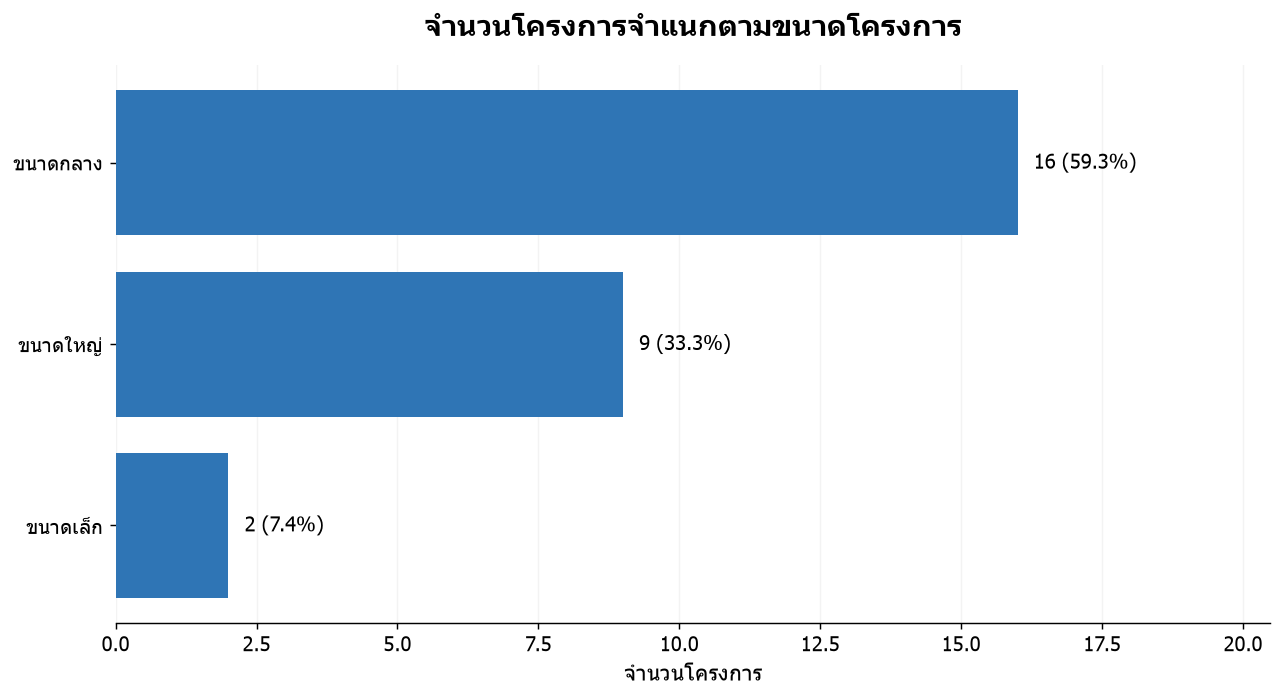

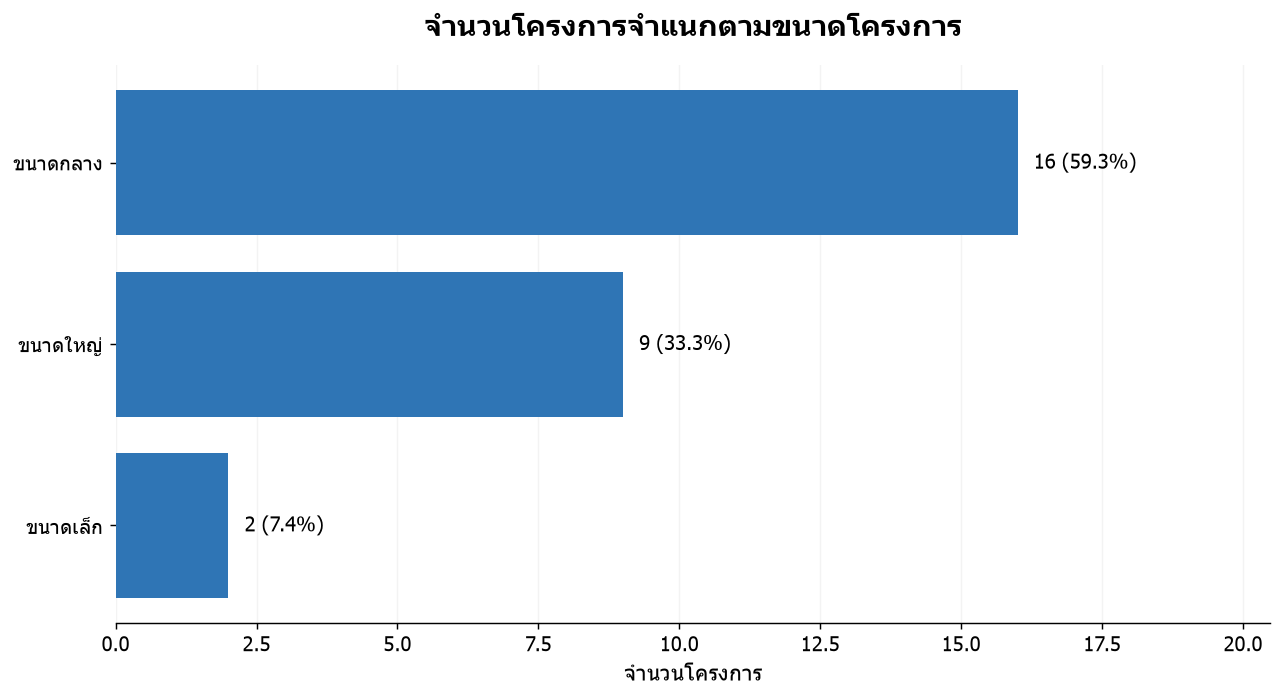

In [ ]:
budget = df["งบประมาณที่ได้รับจัดสรร"]

budget_desc = pd.Series({
    "งบประมาณรวม (ล้านบาท)": budget.sum()/1e6,
    "งบประมาณเฉลี่ย (ล้านบาท/โครงการ)": budget.mean()/1e6,
    "มัธยฐาน (ล้านบาท/โครงการ)": budget.median()/1e6,
    "ต่ำสุด (ล้านบาท)": budget.min()/1e6,
    "สูงสุด (ล้านบาท)": budget.max()/1e6,
})
display(budget_desc.to_frame("ค่า").round(3))

size_col = "ขนาดโครงการ"
size_table = (
    df.groupby(size_col, dropna=False)
      .agg(
          n_projects=("รหัสโครงการ", "count"),
          budget_total=("งบประมาณที่ได้รับจัดสรร", "sum"),
          budget_mean=("งบประมาณที่ได้รับจัดสรร", "mean"),
      )
      .rename(columns={"n_projects":"จำนวน", "budget_total":"งบประมาณรวม", "budget_mean":"งบประมาณเฉลี่ย"})
)
size_table["ร้อยละ"] = size_table["จำนวน"] / N * 100
size_table["สัดส่วนงบประมาณ"] = size_table["งบประมาณรวม"] / budget.sum() * 100
size_table["n (%)"] = [n_pct(n, N) for n in size_table["จำนวน"]]
size_table["งบรวม (ล้านบาท)"] = size_table["งบประมาณรวม"]/1e6
size_table["งบเฉลี่ย (ล้านบาท)"] = size_table["งบประมาณเฉลี่ย"]/1e6

display(size_table[["n (%)", "งบรวม (ล้านบาท)", "สัดส่วนงบประมาณ", "งบเฉลี่ย (ล้านบาท)"]].round(2))
save_table(size_table, "4_2_1_budget_by_project_size.csv")

barh_count(
    size_table[["จำนวน", "ร้อยละ"]],
    "จำนวนโครงการจำแนกตามขนาดโครงการ",
    filename="4_2_1_project_size_count.png",
    color=COLORS["primary"],
    wrap_width=24
)


## 4.2.2 ระยะเวลาและสถานะโครงการ

แสดงทั้ง
1. การกระจายตามระยะเวลา: ต่ำกว่า 1 ปี / 1 ปี / มากกว่า 1 ปี  
2. จำนวนโครงการขยายเวลาและยุติ  
3. สถานะปิดโครงการ โดยคำนวณร้อยละจาก **โครงการที่ไม่ยุติ** ตามกรอบ Word


,ค่า
ระยะเวลาเฉลี่ย (เดือน),10.85
มัธยฐาน (เดือน),12.00
ต่ำสุด (เดือน),6.00
สูงสุด (เดือน),18.00


,จำนวน,ร้อยละ,n (%)
กลุ่มระยะเวลา,,,
ต่ำกว่า 1 ปี,9,33.333333,9 (33.3%)
1 ปี,13,48.148148,13 (48.1%)
มากกว่า 1 ปี,5,18.518519,5 (18.5%)


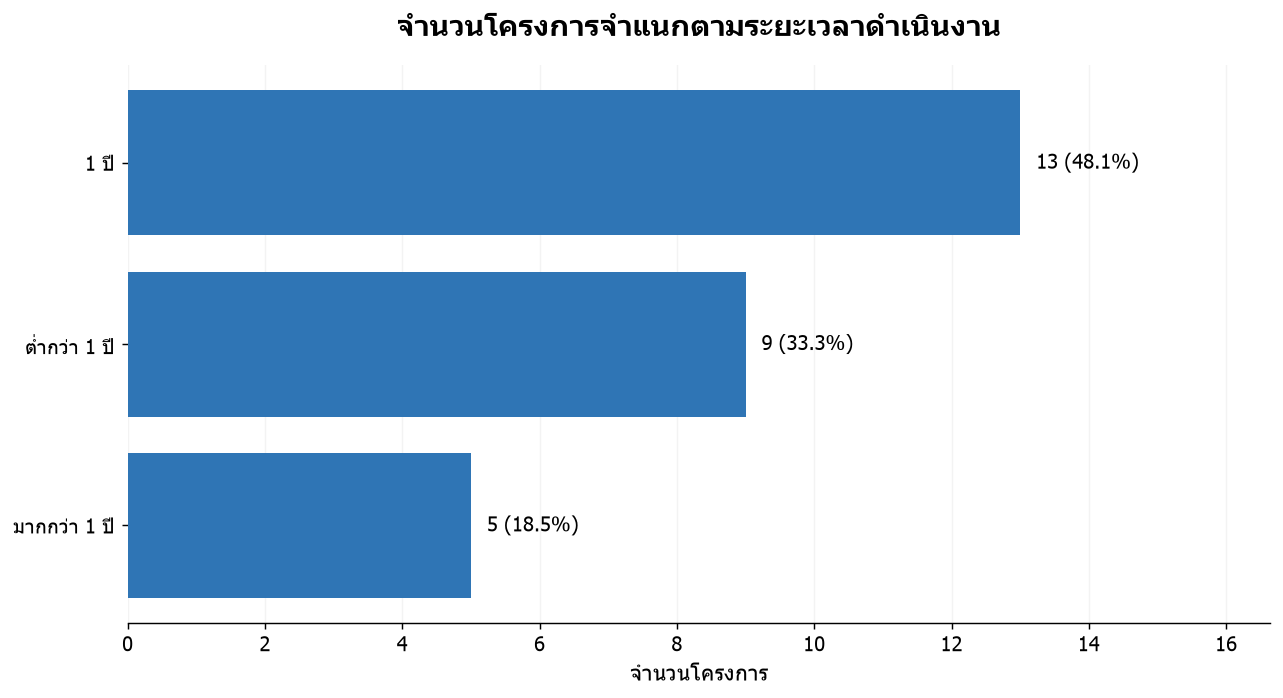

ขยายเวลา: 4 (14.8%)
ยุติโครงการ: 2 (7.4%)


,จำนวน,ร้อยละ,n (%)
ปิดโครงการ,23,92.0,23 (92.0%)
ยังไม่ปิดโครงการ,2,8.0,2 (8.0%)


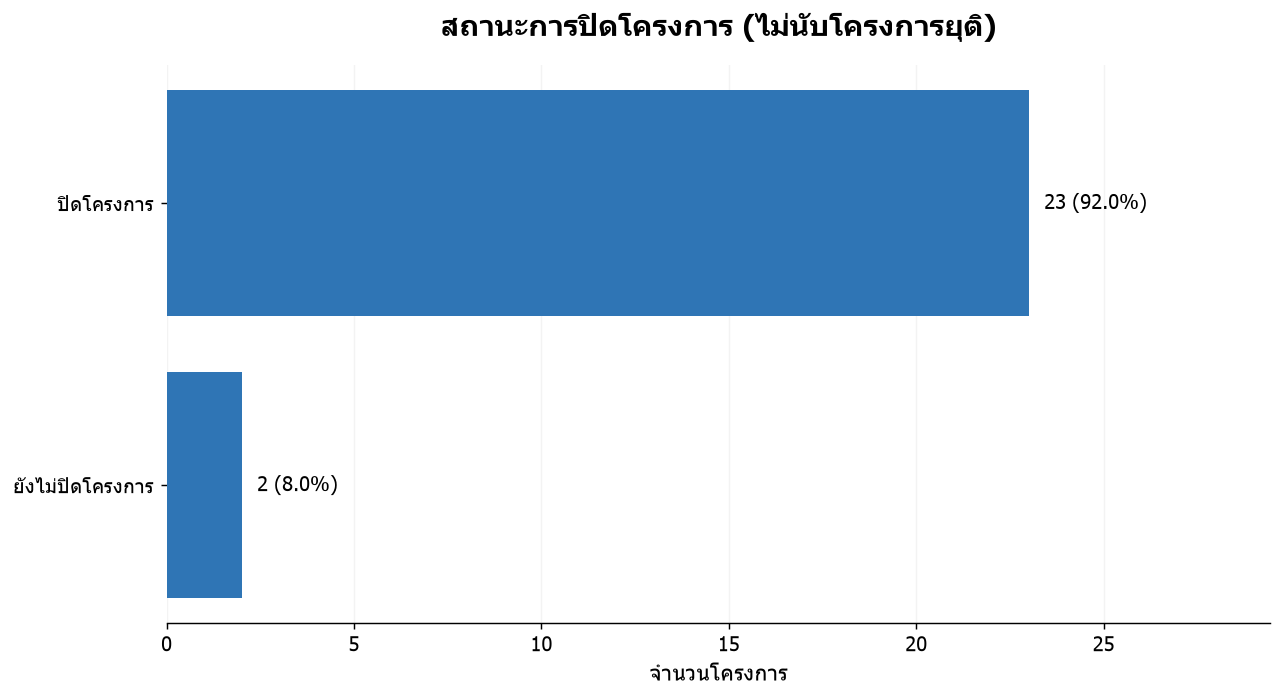

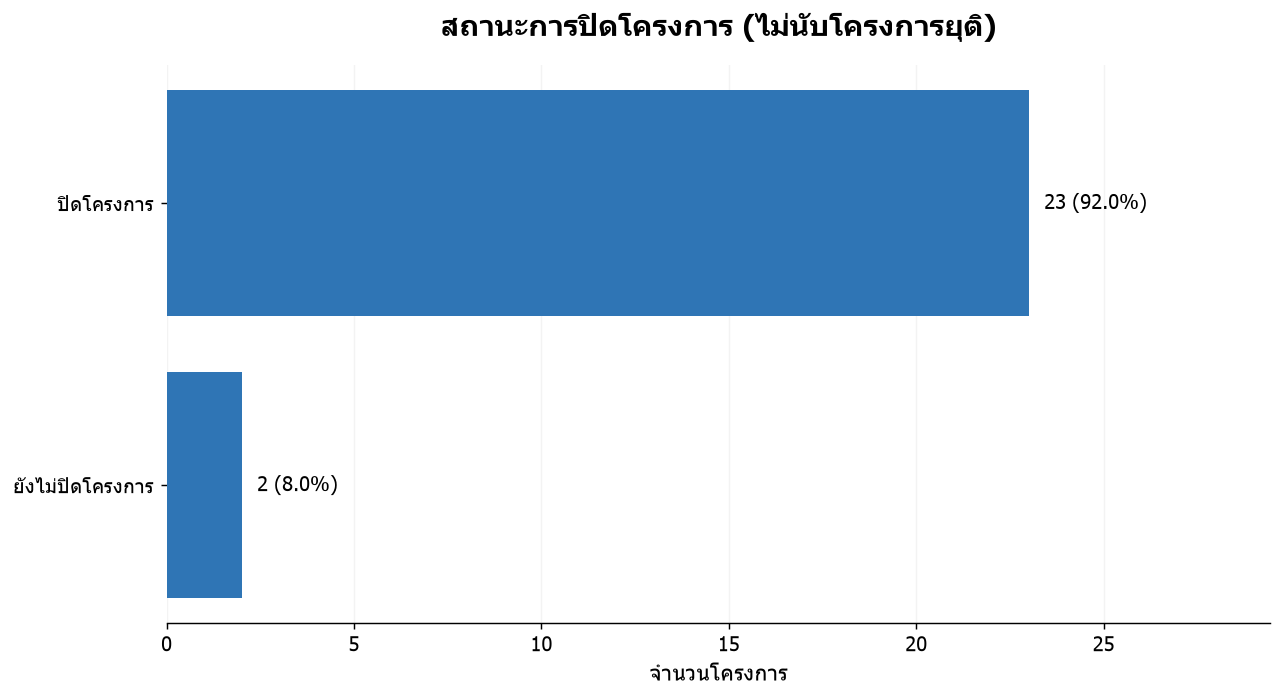

In [ ]:
# ระยะเวลาใช้ปีและเดือนตามจริง
years = pd.to_numeric(df["ระยะเวลาปี"], errors="coerce").fillna(0)
months = pd.to_numeric(df["ระยะเวลาเดือน"], errors="coerce").fillna(0)
duration_months = years*12 + months

df["ระยะเวลารวม_เดือน"] = duration_months

def duration_group(m):
    if pd.isna(m):
        return "ไม่ระบุ"
    if m < 12:
        return "ต่ำกว่า 1 ปี"
    if m == 12:
        return "1 ปี"
    return "มากกว่า 1 ปี"

df["กลุ่มระยะเวลา"] = df["ระยะเวลารวม_เดือน"].map(duration_group)

duration_order = ["ต่ำกว่า 1 ปี", "1 ปี", "มากกว่า 1 ปี", "ไม่ระบุ"]
duration_table = frequency_table(df["กลุ่มระยะเวลา"], denom=N).reindex(
    [x for x in duration_order if x in set(df["กลุ่มระยะเวลา"])]
)

display(pd.Series({
    "ระยะเวลาเฉลี่ย (เดือน)": df["ระยะเวลารวม_เดือน"].mean(),
    "มัธยฐาน (เดือน)": df["ระยะเวลารวม_เดือน"].median(),
    "ต่ำสุด (เดือน)": df["ระยะเวลารวม_เดือน"].min(),
    "สูงสุด (เดือน)": df["ระยะเวลารวม_เดือน"].max(),
}).to_frame("ค่า").round(2))

display(duration_table[["จำนวน", "ร้อยละ", "n (%)"]])
save_table(duration_table, "4_2_2_duration_groups.csv")

barh_count(
    duration_table[["จำนวน", "ร้อยละ"]],
    "จำนวนโครงการจำแนกตามระยะเวลาดำเนินงาน",
    filename="4_2_2_duration_groups.png",
    color=COLORS["primary"],
    wrap_width=24
)

# ขยายเวลา
extension_months = pd.to_numeric(df["ระยะเวลาที่ขยายเวลา (month) (Gift)"], errors="coerce").fillna(0)
extended = extension_months.gt(0)
terminated = df["สถานะงาน"].astype(str).str.contains("ยุติ", na=False)

print("ขยายเวลา:", n_pct(extended.sum(), N))
print("ยุติโครงการ:", n_pct(terminated.sum(), N))

# ปิดโครงการคำนวณเฉพาะโครงการที่ไม่ยุติ
non_terminated = df.loc[~terminated].copy()
closed = non_terminated["สถานะงาน"].astype(str).str.strip().eq("ปิดโครงการ")
close_table = pd.DataFrame({
    "จำนวน": [closed.sum(), (~closed).sum()]
}, index=["ปิดโครงการ", "ยังไม่ปิดโครงการ"])
close_table["ร้อยละ"] = close_table["จำนวน"] / len(non_terminated) * 100
close_table["n (%)"] = [n_pct(n, len(non_terminated)) for n in close_table["จำนวน"]]

display(close_table)
save_table(close_table, "4_2_2_close_status_nonterminated.csv")

barh_count(
    close_table[["จำนวน", "ร้อยละ"]],
    "สถานะการปิดโครงการ (ไม่นับโครงการยุติ)",
    filename="4_2_2_close_status.png",
    color=COLORS["primary"],
    wrap_width=24
)


## 4.2.3 นักวิจัย คณะผู้วิจัย และหน่วยงานร่วมวิจัย

กราฟที่เหมาะ:
- จำนวนนักวิจัยต่อโครงการ → histogram/bar ตามช่วง
- สังกัดหัวหน้าโครงการ → horizontal bar โดยแสดงเฉพาะหน่วยงานที่มีโครงการ


,ค่า
จำนวนนักวิจัยรวม,151.00
เฉลี่ยต่อโครงการ,5.59
มัธยฐาน,5.00
ต่ำสุด,1.00
สูงสุด,24.00


,จำนวน,ร้อยละ,n (%)
กลุ่มจำนวนนักวิจัย,,,
6–10 คน,9,33.333333,9 (33.3%)
1–3 คน,9,33.333333,9 (33.3%)
4–5 คน,8,29.629630,8 (29.6%)
มากกว่า 10 คน,1,3.703704,1 (3.7%)


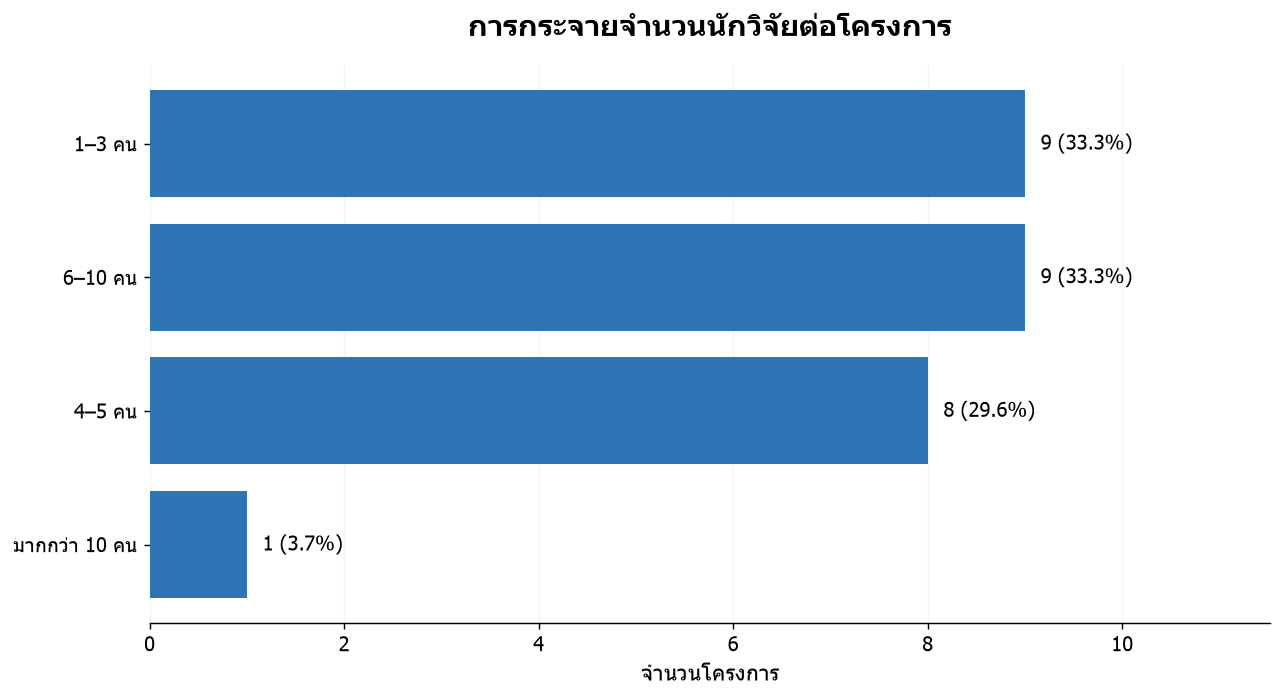

,จำนวน,ร้อยละ,n (%)
สังกัดนักวิจัย,,,
มหาวิทยาลัยเชียงใหม่,4,14.814815,4 (14.8%)
มหาวิทยาลัยนวมินทราธิราช,2,7.407407,2 (7.4%)
มหาวิทยาลัยมหาสารคาม,2,7.407407,2 (7.4%)
สมาคมนิเวศยั่งยืน,2,7.407407,2 (7.4%)
สำนักงานคณะกรรมการสุขภาพแห่งชาติ,2,7.407407,2 (7.4%)
จุฬาลงกรณ์มหาวิทยาลัย,2,7.407407,2 (7.4%)
มหาวิทยาลัยสุโขทัยธรรมาธิราช,1,3.703704,1 (3.7%)
บริษัท เบดร็อค อนาไลติกส์ จำกัด,1,3.703704,1 (3.7%)
มูลนิธิสถาบันวิจัยและพัฒนานโยบาย (สวน),1,3.703704,1 (3.7%)


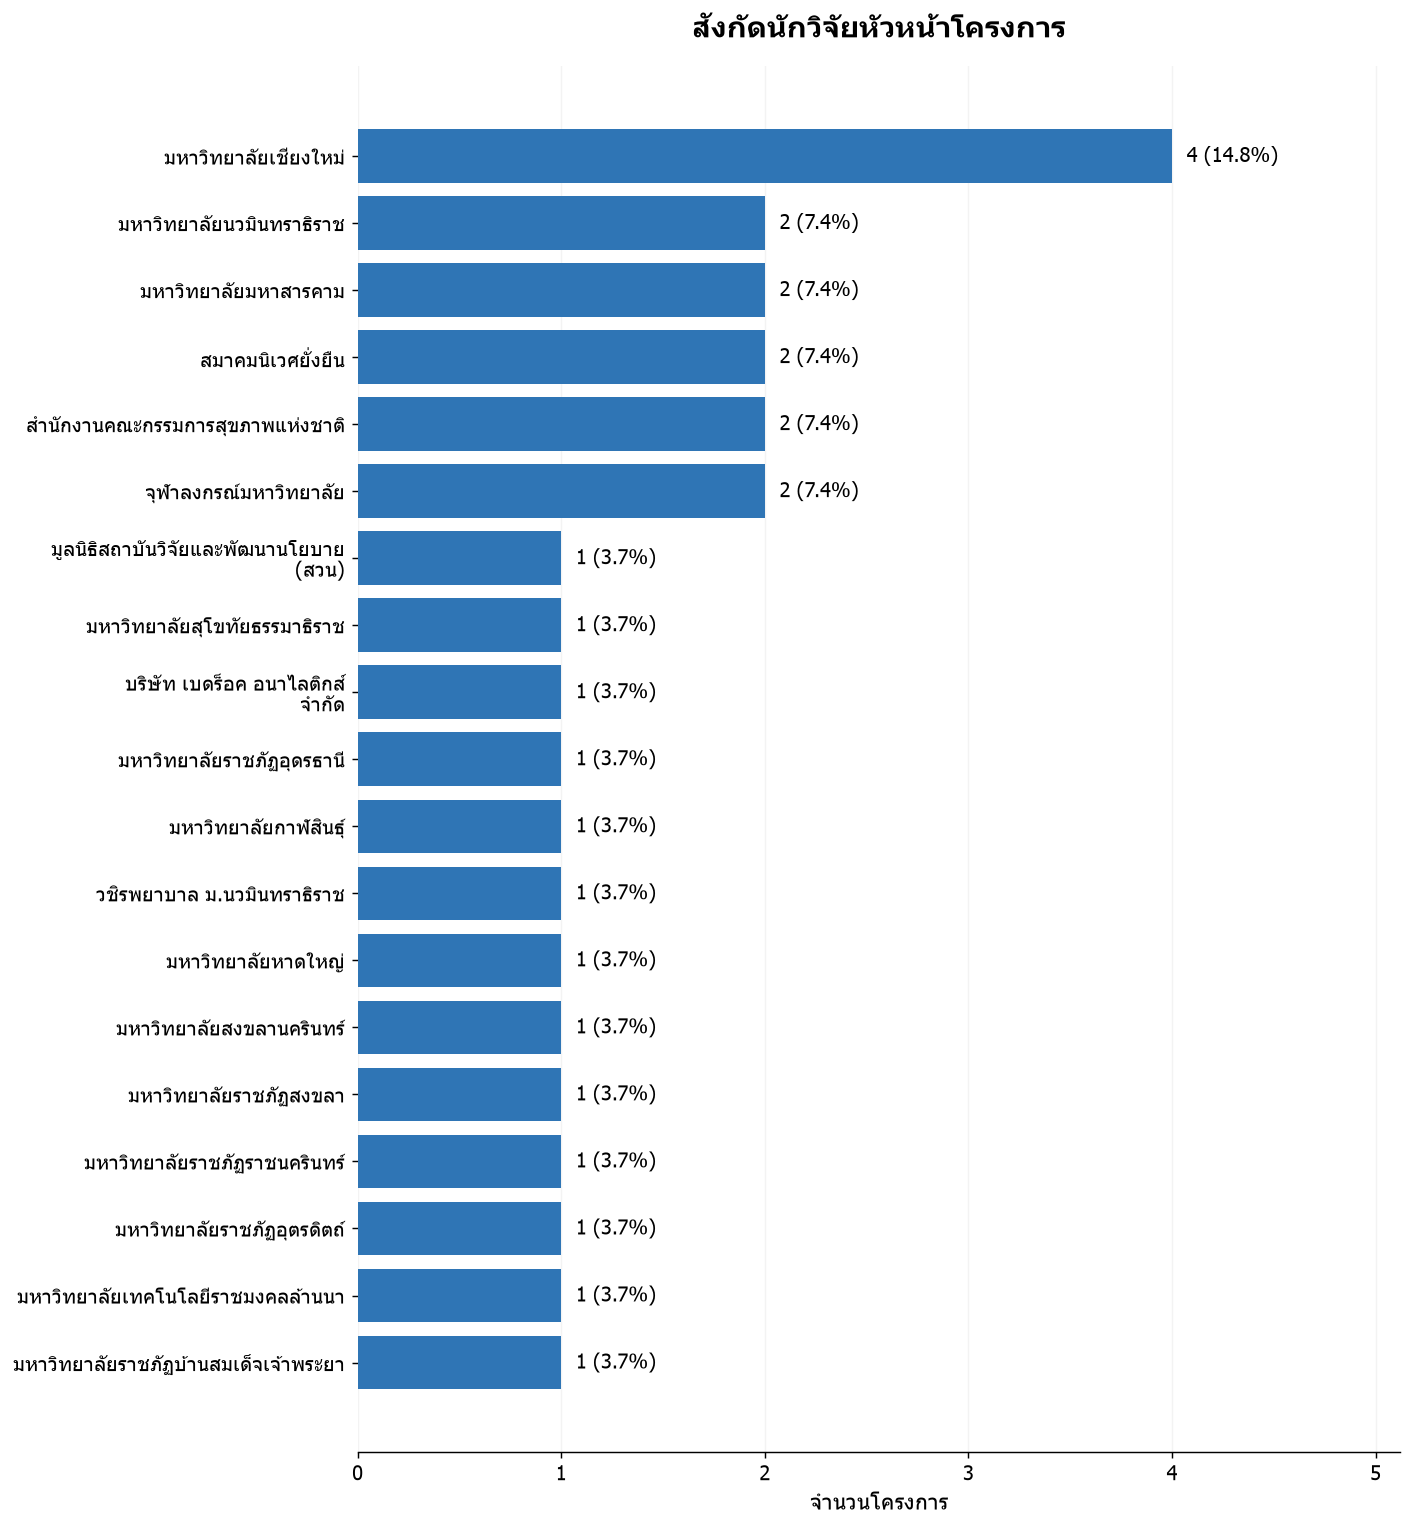

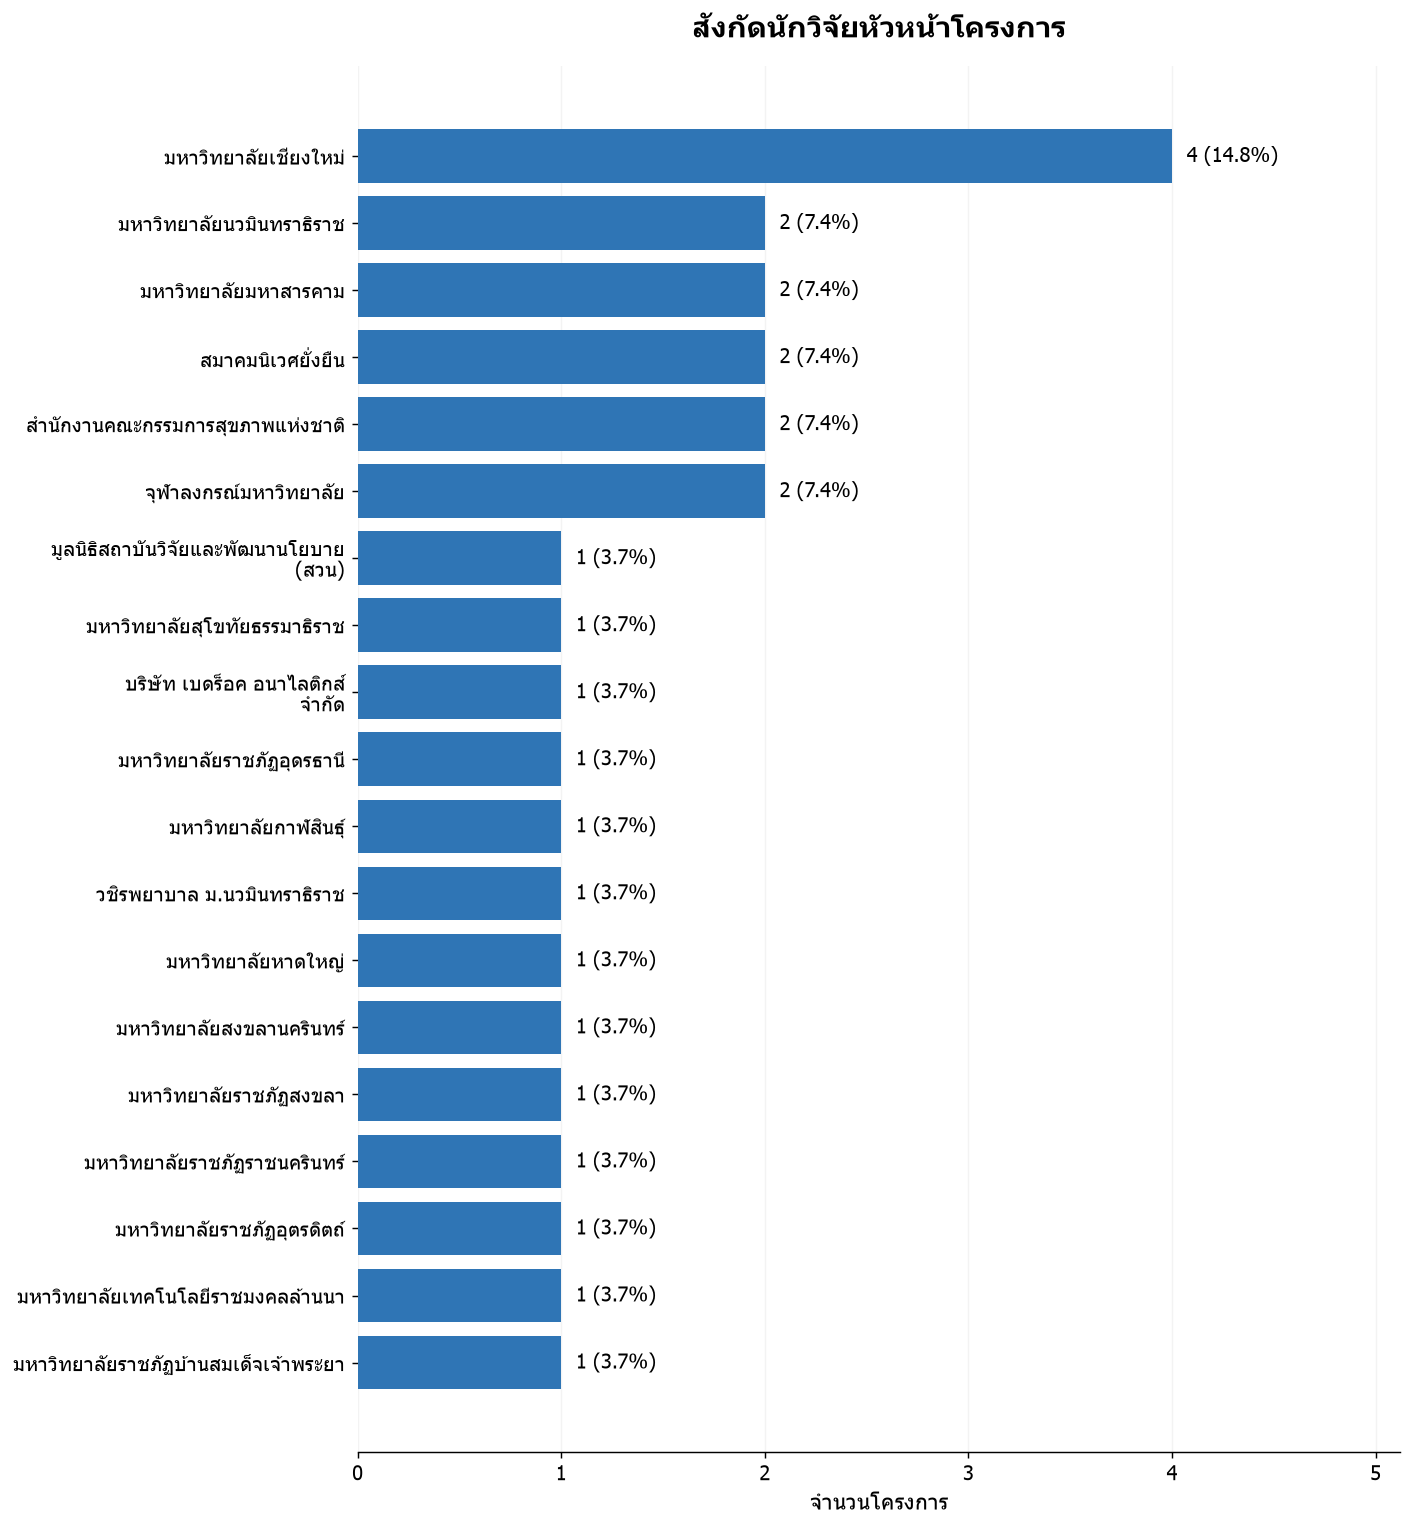

In [ ]:
researcher_n = pd.to_numeric(df["จำนวนนักวิจัย"], errors="coerce")
researcher_summary = pd.Series({
    "จำนวนนักวิจัยรวม": researcher_n.sum(),
    "เฉลี่ยต่อโครงการ": researcher_n.mean(),
    "มัธยฐาน": researcher_n.median(),
    "ต่ำสุด": researcher_n.min(),
    "สูงสุด": researcher_n.max(),
})
display(researcher_summary.to_frame("ค่า").round(2))

bins = [-np.inf, 3, 5, 10, np.inf]
labels = ["1–3 คน", "4–5 คน", "6–10 คน", "มากกว่า 10 คน"]
df["กลุ่มจำนวนนักวิจัย"] = pd.cut(researcher_n, bins=bins, labels=labels)
researcher_group = frequency_table(df["กลุ่มจำนวนนักวิจัย"].astype(object), denom=N)
display(researcher_group[["จำนวน", "ร้อยละ", "n (%)"]])

barh_count(
    researcher_group[["จำนวน", "ร้อยละ"]],
    "การกระจายจำนวนนักวิจัยต่อโครงการ",
    filename="4_2_3_researcher_team_size.png",
    color=COLORS["primary"],
    wrap_width=24
)

aff = frequency_table(df["สังกัดนักวิจัย"], denom=N)
display(aff[["จำนวน", "ร้อยละ", "n (%)"]])
save_table(aff, "4_2_3_pi_affiliations.csv")

barh_count(
    aff[["จำนวน", "ร้อยละ"]],
    "สังกัดนักวิจัยหัวหน้าโครงการ",
    filename="4_2_3_pi_affiliations.png",
    label_map=AFFILIATION_LABELS,
    wrap_width=28,
    color=COLORS["primary"],
    figsize=(11, max(6, 0.52*len(aff)+2))
)


# 4.3 การดำเนินงานของแผนงานวิจัย

## 4.3.1 หน่วยงานผู้รับทุน
ส่วนนี้ Word ระบุให้เขียนบรรยาย จึงใช้ตารางสังกัดจาก 4.2.3 เป็นข้อมูลประกอบ

## 4.3.2 ประเภทของงานวิจัย
วิเคราะห์ทั้งประเภทการวิจัยหลัก และประเภทการวิจัยตามกรอบ บพท. แบบ multiple response


,จำนวน,ร้อยละ,n (%)
ประเภทของการวิจัย,,,
การวิจัยเชิงประยุกต์,21,77.777778,21 (77.8%)
การพัฒนาเชิงทดลอง,3,11.111111,3 (11.1%)
การวิจัยเชิงนโยบาย,3,11.111111,3 (11.1%)


,จำนวน,ร้อยละ,งบเฉลี่ย (ล้านบาท)
ประเภทของการวิจัย,,,
การพัฒนาเชิงทดลอง,3,11.11,3.01
การวิจัยเชิงนโยบาย,3,11.11,1.11
การวิจัยเชิงประยุกต์,21,77.78,3.70


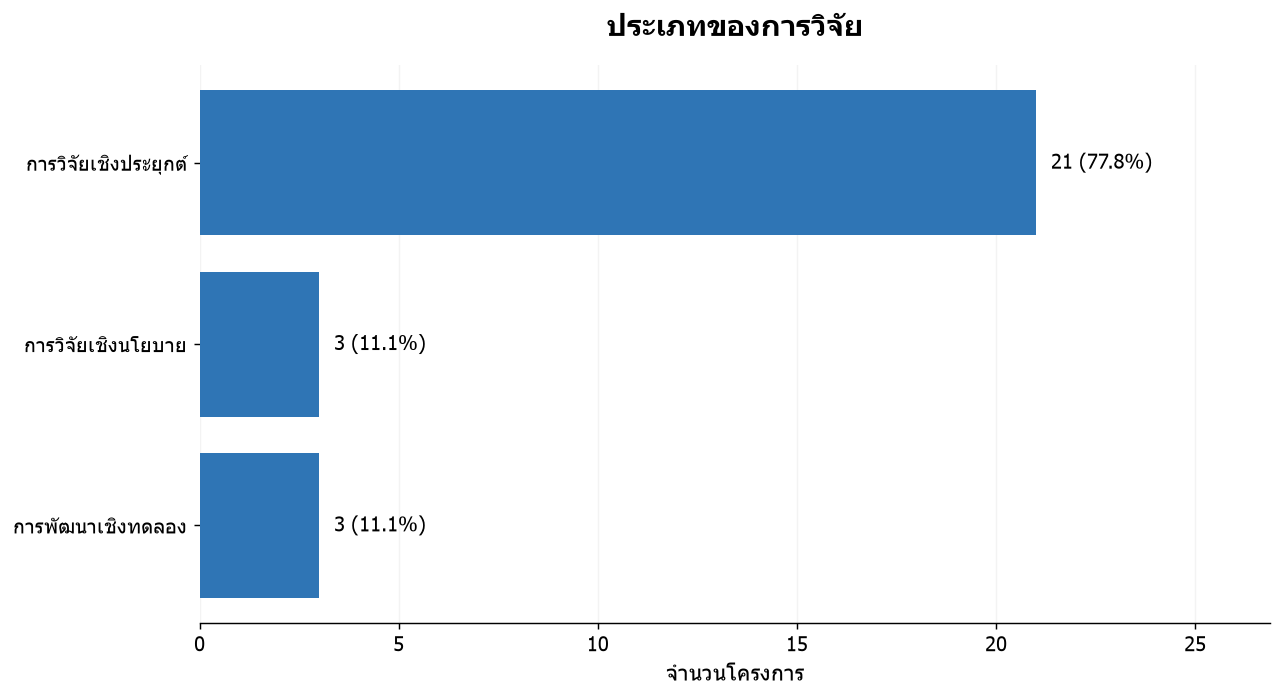

ขนาดโครงการ,ขนาดกลาง,ขนาดเล็ก,ขนาดใหญ่,All
ประเภทของการวิจัย,,,,
การพัฒนาเชิงทดลอง,0,1,2,3
การวิจัยเชิงนโยบาย,3,0,0,3
การวิจัยเชิงประยุกต์,13,1,7,21
All,16,2,9,27


,จำนวน,ร้อยละ,n (%)
ประเภทตามกรอบ_บพท.,,,
การพัฒนากลไกการจัดบริการสาธารณะขององค์กรปกครองส่วนท้องถิ่น (User คือ ช่วยชาวบ้านในพื้นที่),17,62.962963,17 (63.0%)
การพัฒนาเทคโนโลยีดิจิทัล (User คือ อปท. เพื่อพัฒนาการทำงาน),11,40.740741,11 (40.7%)
การพัฒนากลไกและกระบวนการสร้างการเปลี่ยนแปลงเพื่อเพิ่มรายได้ของท้องถิ่น,7,25.925926,7 (25.9%)
การพัฒนาศักยภาพเชิงสถาบันและกรอบกฎหมาย,3,11.111111,3 (11.1%)
การพัฒนากลไกการจัดบริการสาธารณะขององค์กรปกครองส่วนท้องถิ่น,2,7.407407,2 (7.4%)
การพัฒนาเทคโนโลยีดิจิทัล,1,3.703704,1 (3.7%)
เป็นการพัฒนาศักยภาพนักวิจัย เพื่อตอบสนองต่อการพัฒนาปสภ.การทำงานของ อปท.,1,3.703704,1 (3.7%)
เป็นการพัฒนาสมรรถนะใรการบริหารจัดการน้ำ ซึ่งเป็นบริการสาธารณะของ อปท.,1,3.703704,1 (3.7%)


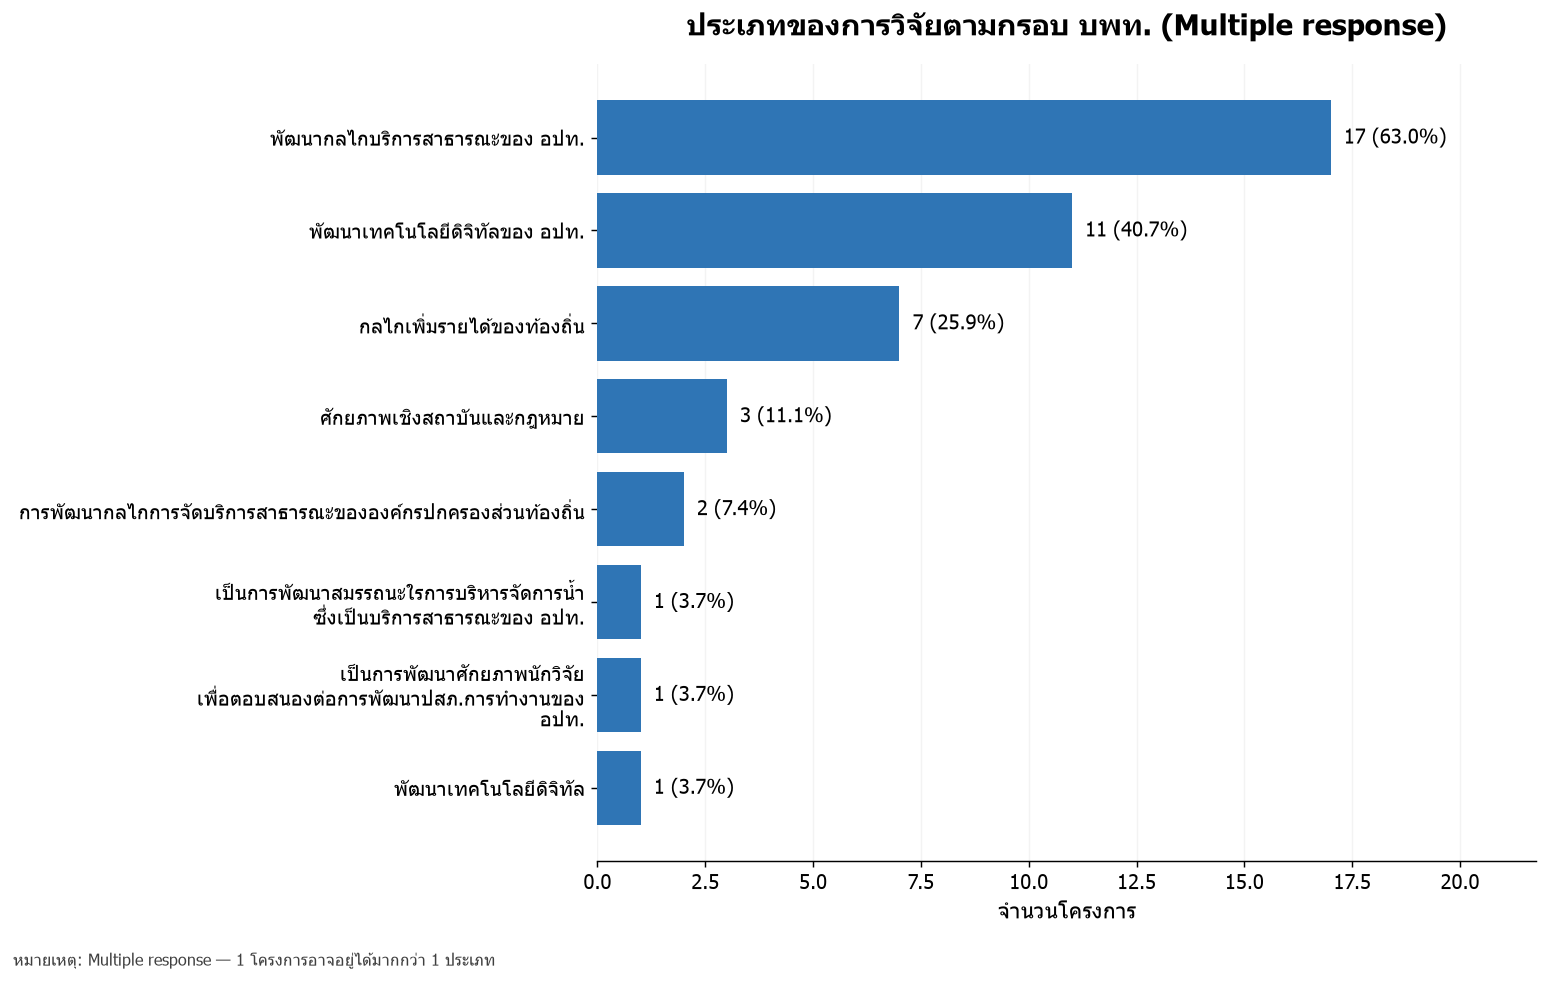

,จำนวน,ร้อยละโครงการ,งบเฉลี่ย (ล้านบาท)
ประเภทตามกรอบ_บพท.,,,
การพัฒนากลไกการจัดบริการสาธารณะขององค์กรปกครองส่วนท้องถิ่น,2,7.41,5.27
การพัฒนากลไกการจัดบริการสาธารณะขององค์กรปกครองส่วนท้องถิ่น (User คือ ช่วยชาวบ้านในพื้นที่),17,62.96,3.72
การพัฒนากลไกและกระบวนการสร้างการเปลี่ยนแปลงเพื่อเพิ่มรายได้ของท้องถิ่น,7,25.93,4.91
การพัฒนาศักยภาพเชิงสถาบันและกรอบกฎหมาย,3,11.11,7.85
การพัฒนาเทคโนโลยีดิจิทัล,1,3.70,0.40
การพัฒนาเทคโนโลยีดิจิทัล (User คือ อปท. เพื่อพัฒนาการทำงาน),11,40.74,4.11
เป็นการพัฒนาศักยภาพนักวิจัย เพื่อตอบสนองต่อการพัฒนาปสภ.การทำงานของ อปท.,1,3.70,4.50
เป็นการพัฒนาสมรรถนะใรการบริหารจัดการน้ำ ซึ่งเป็นบริการสาธารณะของ อปท.,1,3.70,4.02


In [ ]:
research_type_col = "ประเภทของการวิจัย"
research_type = frequency_table(df[research_type_col], denom=N)
display(research_type[["จำนวน", "ร้อยละ", "n (%)"]])

type_budget = (
    df.groupby(research_type_col)
      .agg(
          n_projects=("รหัสโครงการ", "count"),
          budget_mean=("งบประมาณที่ได้รับจัดสรร", "mean"),
          budget_total=("งบประมาณที่ได้รับจัดสรร", "sum")
      )
      .rename(columns={"n_projects":"จำนวน", "budget_mean":"งบประมาณเฉลี่ย", "budget_total":"งบประมาณรวม"})
)
type_budget["ร้อยละ"] = type_budget["จำนวน"]/N*100
type_budget["งบเฉลี่ย (ล้านบาท)"] = type_budget["งบประมาณเฉลี่ย"]/1e6
display(type_budget[["จำนวน", "ร้อยละ", "งบเฉลี่ย (ล้านบาท)"]].round(2))

barh_count(
    research_type[["จำนวน", "ร้อยละ"]],
    "ประเภทของการวิจัย",
    filename="4_3_2_research_type.png",
    color=COLORS["primary"],
    wrap_width=28
)

# ประเภทการวิจัย x ขนาดโครงการ
cross_type_size = pd.crosstab(
    df[research_type_col].map(clean_text),
    df["ขนาดโครงการ"].map(clean_text),
    margins=True
)
display(cross_type_size)

# ประเภทงานวิจัยตามกรอบ บพท. เป็น multiple response
pmu_cols = [
    "ประเภทของการวิจัยตามกรอบ บพท. (1) (Gift)",
    "ประเภทของการวิจัยตามกรอบ (2) บพท. (Gift)",
    "ประเภทของการวิจัยตามกรอบ (3) (Gift)"
]
pmu_long = (
    df[["รหัสโครงการ", "ขนาดโครงการ", "งบประมาณที่ได้รับจัดสรร"] + pmu_cols]
      .melt(
          id_vars=["รหัสโครงการ", "ขนาดโครงการ", "งบประมาณที่ได้รับจัดสรร"],
          value_vars=pmu_cols,
          value_name="ประเภทตามกรอบ_บพท."
      )
      .dropna(subset=["ประเภทตามกรอบ_บพท."])
)
pmu_long["ประเภทตามกรอบ_บพท."] = pmu_long["ประเภทตามกรอบ_บพท."].map(clean_text)
pmu_long = pmu_long.drop_duplicates(["รหัสโครงการ", "ประเภทตามกรอบ_บพท."])

pmu_count = pmu_long["ประเภทตามกรอบ_บพท."].value_counts()
pmu_table = pd.DataFrame({"จำนวน": pmu_count})
pmu_table["ร้อยละ"] = pmu_table["จำนวน"]/N*100
pmu_table["n (%)"] = [n_pct(n, N) for n in pmu_table["จำนวน"]]
display(pmu_table)

barh_count(
    pmu_table[["จำนวน", "ร้อยละ"]],
    "ประเภทของการวิจัยตามกรอบ บพท. (Multiple response)",
    filename="4_3_2_pmu_research_framework.png",
    label_map=PMU_LABELS,
    wrap_width=32,
    color=COLORS["primary"],
    figsize=(12, max(6, 0.7*len(pmu_table)+2)),
    note="หมายเหตุ: Multiple response — 1 โครงการอาจอยู่ได้มากกว่า 1 ประเภท"
)

pmu_budget = (
    pmu_long.groupby("ประเภทตามกรอบ_บพท.")
      .agg(
          n_projects=("รหัสโครงการ", "nunique"),
          budget_mean=("งบประมาณที่ได้รับจัดสรร", "mean")
      )
      .rename(columns={"n_projects":"จำนวน", "budget_mean":"งบประมาณเฉลี่ย"})
)
pmu_budget["ร้อยละโครงการ"] = pmu_budget["จำนวน"]/N*100
pmu_budget["งบเฉลี่ย (ล้านบาท)"] = pmu_budget["งบประมาณเฉลี่ย"]/1e6
display(pmu_budget[["จำนวน", "ร้อยละโครงการ", "งบเฉลี่ย (ล้านบาท)"]].round(2))


## 4.3.3 สาขางานวิจัย (OECD)

ใช้ `สาขาการวิจัย (OECD1)` เป็นสาขาหลักตามกรอบ Word และแสดงจำนวน/ร้อยละกำกับทุกแท่ง


,จำนวน,ร้อยละ,n (%)
สาขาการวิจัย (OECD1),,,
5. สังคมศาสตร์ (Social Sciences),18,66.666667,18 (66.7%)
2. วิศวกรรมและเทคโนโลยี (Engineering and technology),8,29.629630,8 (29.6%)
3. วิทยาศาสตร์การแพทย์และสุขภาพ (Medical and Health Sciences),1,3.703704,1 (3.7%)


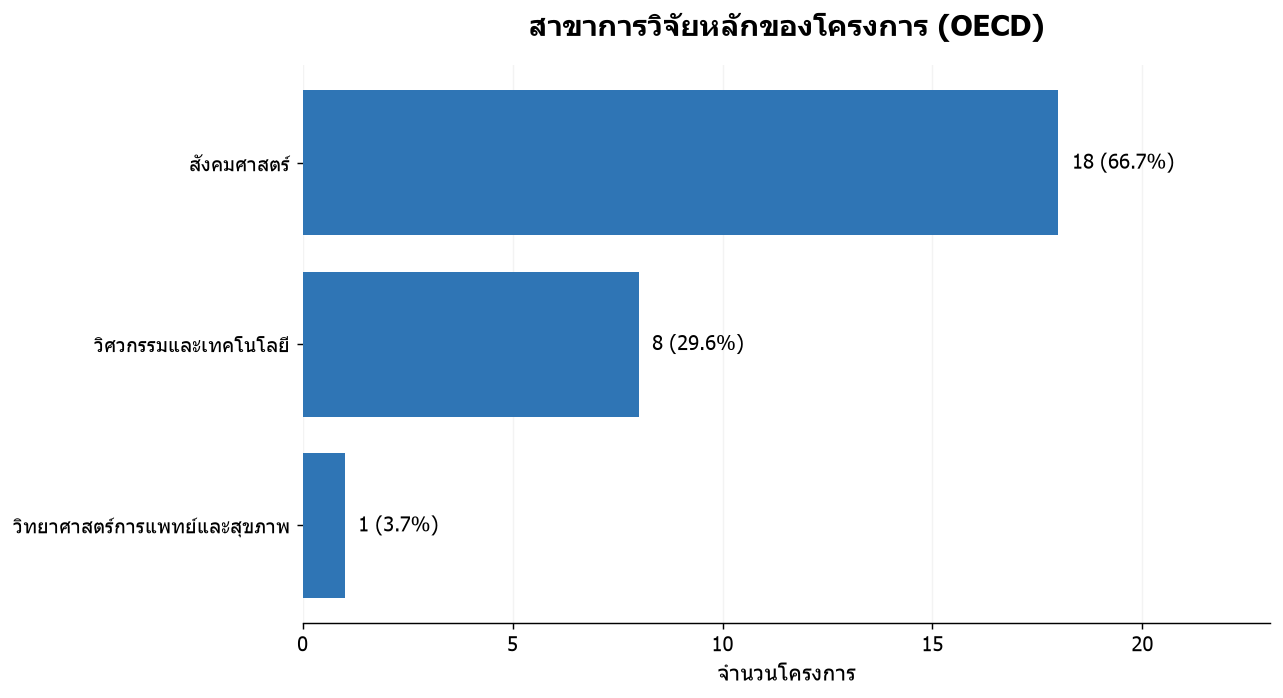

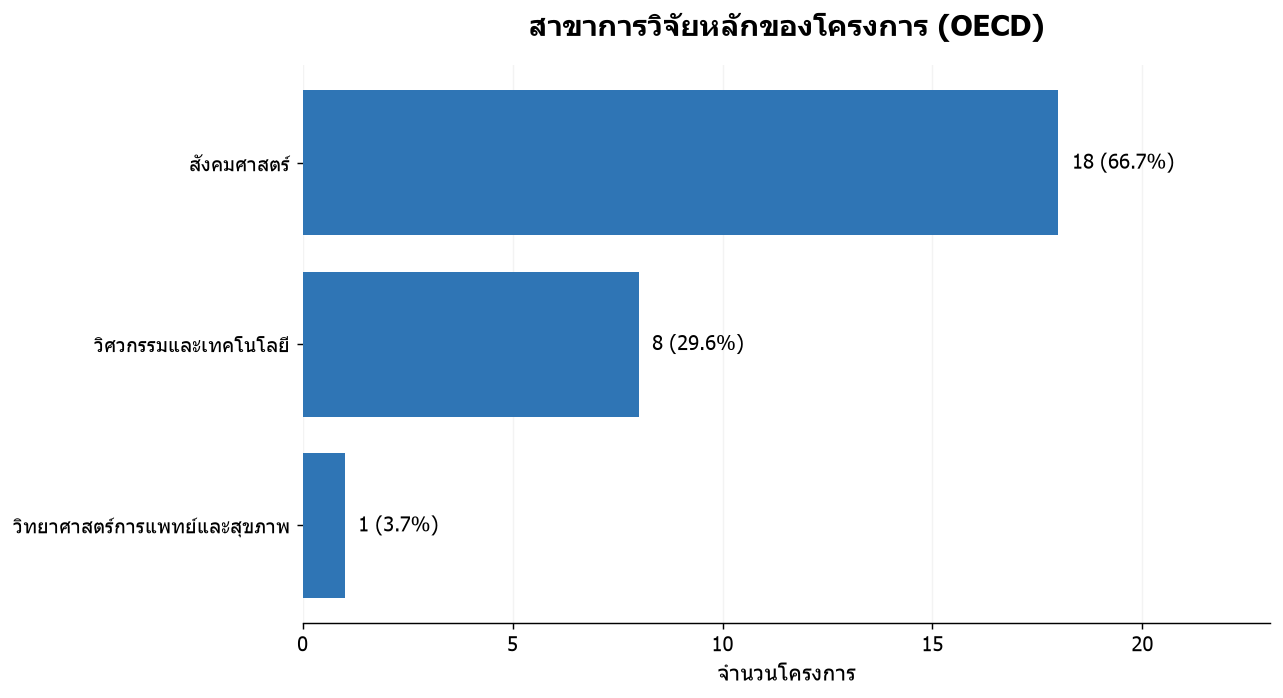

In [ ]:
oecd_field = frequency_table(df["สาขาการวิจัย (OECD1)"], denom=N)
display(oecd_field[["จำนวน", "ร้อยละ", "n (%)"]])
save_table(oecd_field, "4_3_3_oecd_research_field.csv")

barh_count(
    oecd_field[["จำนวน", "ร้อยละ"]],
    "สาขาการวิจัยหลักของโครงการ (OECD)",
    filename="4_3_3_oecd_research_field.png",
    label_map=OECD_FIELD_LABELS,
    wrap_width=28,
    color=COLORS["primary"]
)


# 4.4 ผลผลิตของแผนงานวิจัย

## 4.4.1 ประเภทของผลผลิต

หนึ่งโครงการอาจมีผลผลิตได้หลายประเภท จึงแปลงผลผลิตลำดับที่ 1–6 เป็น long format ก่อนนับ  
**ข้อควรระวัง:** หากนำงบประมาณโครงการไปผูกกับผลผลิตหลายประเภท งบประมาณจะถูกนับซ้ำเมื่อรวมข้ามประเภท ดังนั้นตารางนี้เหมาะสำหรับเปรียบเทียบ “งบของโครงการที่มีผลผลิตประเภทนั้น” ไม่ควรนำยอดข้ามประเภทมาบวกเป็นงบรวมแผนงาน


,จำนวน,ร้อยละ,n (%)
ประเภทผลผลิต,,,
ฐานข้อมูล ระบบและกลไก,20,74.074074,20 (74.1%)
กำลังคน หรือหน่วยงาน ที่ได้รับการพัฒนาทักษะ,17,62.962963,17 (63.0%)
นวัตกรรมทางสังคม,10,37.037037,10 (37.0%)
เครือข่าย,10,37.037037,10 (37.0%)
อื่นๆ,8,29.629630,8 (29.6%)
ข้อเสนอแนะเชิงนโยบาย:ข้อเสนอที่มุ่งใช้ประกอบการตัดสินใจ การกำหนดนโยบาย มาตรการ แผนงาน แนวทางปฏิบัติ หรือกฎเกณฑ์ของหน่วยงานหรือองค์กร,6,22.222222,6 (22.2%)
ต้นแบบผลิตภัณฑ์,5,18.518519,5 (18.5%)
ข้อเสนอแนะเชิงนโยบาย,5,18.518519,5 (18.5%)
เครื่องมือ และโครงสร้างพื้นฐานที่สร้างขึ้น หรือพัฒนาต่อยอดภายใต้โครงการ,3,11.111111,3 (11.1%)


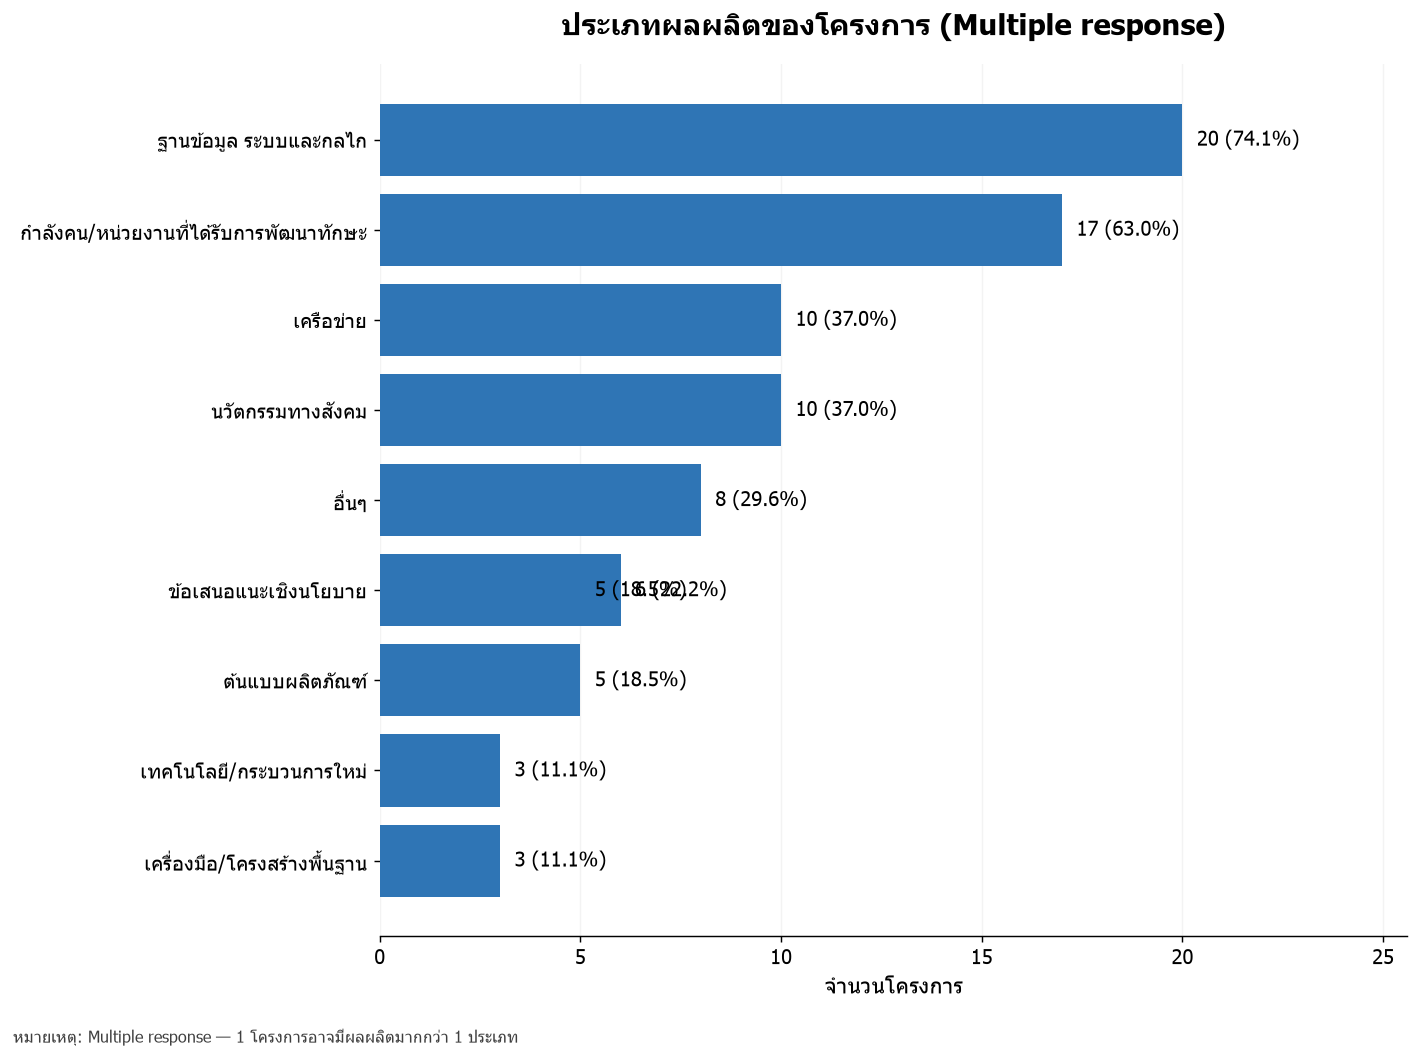

ประเภทของการวิจัย,การพัฒนาเชิงทดลอง,การวิจัยเชิงนโยบาย,การวิจัยเชิงประยุกต์
ประเภทผลผลิต,,,
กำลังคน หรือหน่วยงาน ที่ได้รับการพัฒนาทักษะ,3,0,14
ข้อเสนอแนะเชิงนโยบาย,1,1,3
ข้อเสนอแนะเชิงนโยบาย:ข้อเสนอที่มุ่งใช้ประกอบการตัดสินใจ การกำหนดนโยบาย มาตรการ แผนงาน แนวทางปฏิบัติ หรือกฎเกณฑ์ของหน่วยงานหรือองค์กร,1,2,3
ฐานข้อมูล ระบบและกลไก,2,3,15
ต้นแบบผลิตภัณฑ์,3,0,2
นวัตกรรมทางสังคม,0,0,10
อื่นๆ,0,0,8
เครือข่าย,3,0,7
เครื่องมือ และโครงสร้างพื้นฐานที่สร้างขึ้น หรือพัฒนาต่อยอดภายใต้โครงการ,1,1,1


,จำนวนโครงการ,งบรวมของโครงการ (ล้านบาท),งบเฉลี่ยต่อโครงการ (ล้านบาท)
ประเภทผลผลิต,,,
กำลังคน หรือหน่วยงาน ที่ได้รับการพัฒนาทักษะ,17,68.68,4.04
ข้อเสนอแนะเชิงนโยบาย,5,13.25,2.65
ข้อเสนอแนะเชิงนโยบาย:ข้อเสนอที่มุ่งใช้ประกอบการตัดสินใจ การกำหนดนโยบาย มาตรการ แผนงาน แนวทางปฏิบัติ หรือกฎเกณฑ์ของหน่วยงานหรือองค์กร,6,40.75,6.79
ฐานข้อมูล ระบบและกลไก,20,76.88,3.84
ต้นแบบผลิตภัณฑ์,5,15.54,3.11
นวัตกรรมทางสังคม,10,44.05,4.40
อื่นๆ,8,30.30,3.79
เครือข่าย,10,48.20,4.82
เครื่องมือ และโครงสร้างพื้นฐานที่สร้างขึ้น หรือพัฒนาต่อยอดภายใต้โครงการ,3,10.74,3.58


In [ ]:
output_cols = [
    "ผลผลิตหลัก ลำดับที่ 1",
    "ผลผลิตหลัก ลำดับที่ 2",
    "ผลผลิตหลัก ลำดับที่ 3",
    "ผลผลิตหลัก ลำดับที่ 4",
    "ผลผลิตหลัก ลำดับที่ 5",
    "ผลผลิตหลัก ลำดับที่ 6",
]

output_long = (
    df[["รหัสโครงการ", research_type_col, "งบประมาณที่ได้รับจัดสรร"] + output_cols]
      .melt(
          id_vars=["รหัสโครงการ", research_type_col, "งบประมาณที่ได้รับจัดสรร"],
          value_vars=output_cols,
          value_name="ประเภทผลผลิต"
      )
      .dropna(subset=["ประเภทผลผลิต"])
)
output_long["ประเภทผลผลิต"] = output_long["ประเภทผลผลิต"].map(clean_text)
output_long = output_long.drop_duplicates(["รหัสโครงการ", "ประเภทผลผลิต"])

output_count = output_long["ประเภทผลผลิต"].value_counts()
output_table = pd.DataFrame({"จำนวน": output_count})
output_table["ร้อยละ"] = output_table["จำนวน"]/N*100
output_table["n (%)"] = [n_pct(n, N) for n in output_table["จำนวน"]]

display(output_table)
save_table(output_table, "4_4_1_output_types.csv")

barh_count(
    output_table[["จำนวน", "ร้อยละ"]],
    "ประเภทผลผลิตของโครงการ (Multiple response)",
    filename="4_4_1_output_types.png",
    label_map=OUTPUT_LABELS,
    wrap_width=30,
    color=COLORS["primary"],
    figsize=(11, max(6, 0.62*len(output_table)+2)),
    note="หมายเหตุ: Multiple response — 1 โครงการอาจมีผลผลิตมากกว่า 1 ประเภท"
)

# ผลผลิต x ประเภทการวิจัย
output_by_type = pd.crosstab(
    output_long["ประเภทผลผลิต"],
    output_long[research_type_col]
)
display(output_by_type)

# งบประมาณของโครงการที่มีผลผลิตแต่ละประเภท
output_budget = (
    output_long.groupby("ประเภทผลผลิต")
      .agg(
          n_projects=("รหัสโครงการ", "nunique"),
          budget_total=("งบประมาณที่ได้รับจัดสรร", "sum"),
          budget_mean=("งบประมาณที่ได้รับจัดสรร", "mean")
      )
      .rename(columns={
          "n_projects":"จำนวนโครงการ",
          "budget_total":"งบประมาณรวมของโครงการ",
          "budget_mean":"งบประมาณเฉลี่ยต่อโครงการ"
      })
)
output_budget["งบรวมของโครงการ (ล้านบาท)"] = output_budget["งบประมาณรวมของโครงการ"]/1e6
output_budget["งบเฉลี่ยต่อโครงการ (ล้านบาท)"] = output_budget["งบประมาณเฉลี่ยต่อโครงการ"]/1e6
display(
    output_budget[
        ["จำนวนโครงการ", "งบรวมของโครงการ (ล้านบาท)", "งบเฉลี่ยต่อโครงการ (ล้านบาท)"]
    ].round(2)
)


## 4.4.2 TRL ณ สิ้นสุดโครงการ

กราฟใช้ระดับ TRL เรียงจากต่ำไปสูง ไม่เรียงตามจำนวน เพื่อให้เห็น “ระดับความพร้อม” เป็นลำดับต่อเนื่อง


,จำนวน,ร้อยละ,งบรวม (ล้านบาท),สัดส่วนงบประมาณ
TRL สิ้นสุด (Gift),,,,
TRL 3,2,7.41,2.0,2.22
TRL 4,1,3.70,1.0,1.11
TRL 5,4,14.81,11.4,12.67
TRL 6,13,48.15,52.2,57.99
TRL 7,4,14.81,16.9,18.77
TRL 8,1,3.70,3.0,3.33
N/A,2,7.41,3.5,3.89


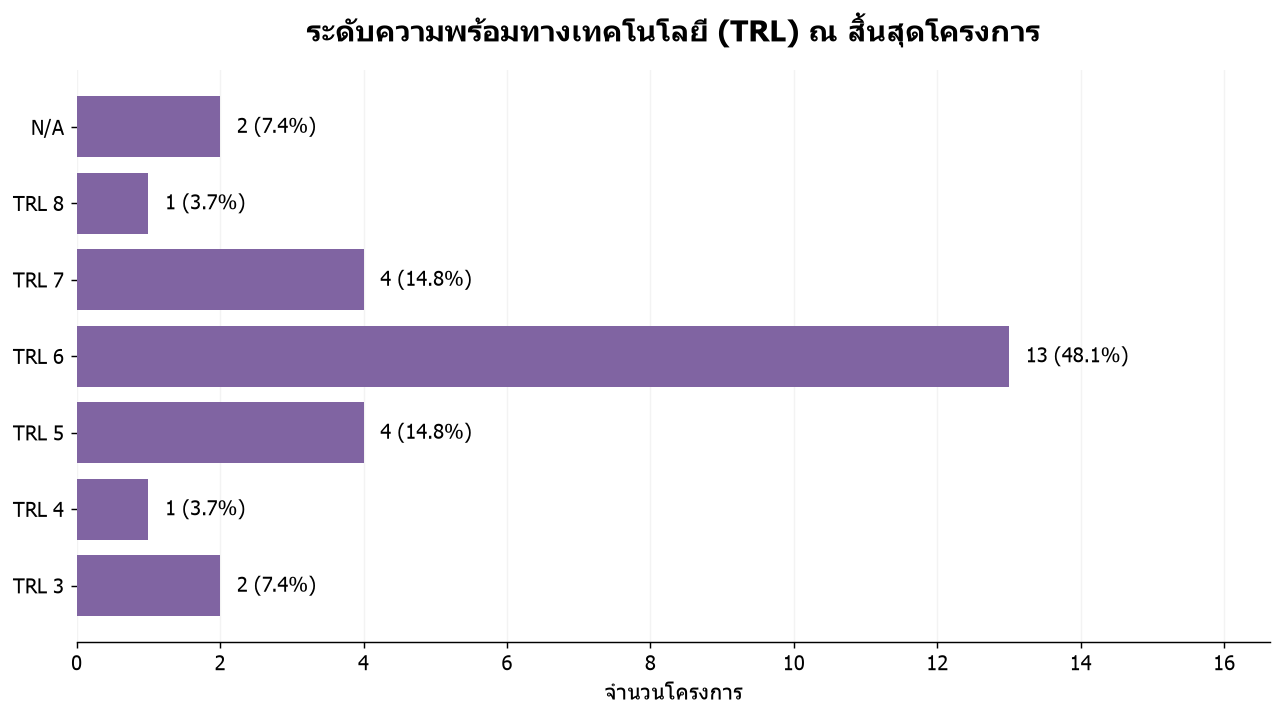

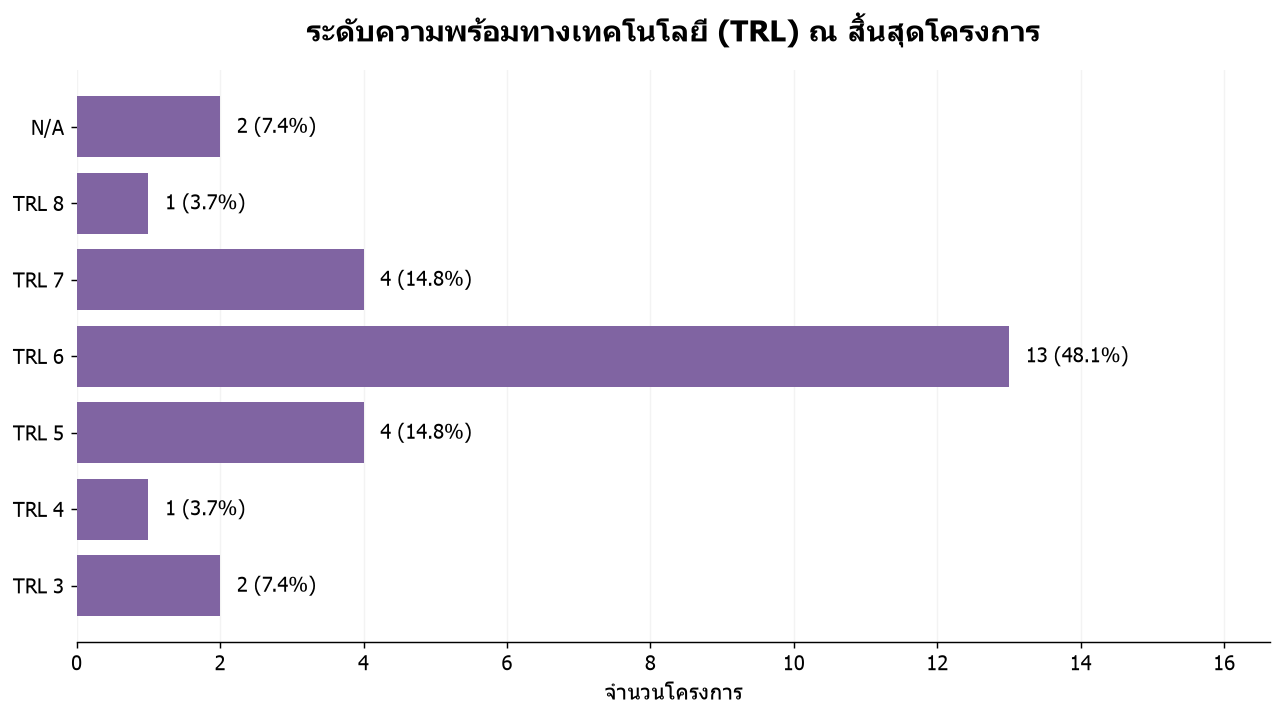

In [ ]:
trl = numeric_prefix(df["TRL สิ้นสุด (Gift)"])
trl_label = trl.map(lambda x: f"TRL {int(x)}" if pd.notna(x) else "N/A")
trl_table = frequency_table(trl_label, denom=N, sort=False)

trl_order = [f"TRL {i}" for i in range(1,10)] + ["N/A"]
trl_table = trl_table.reindex([x for x in trl_order if x in trl_table.index])

# เพิ่มงบ
trl_budget = (
    df.assign(TRL_label=trl_label)
      .groupby("TRL_label", dropna=False)["งบประมาณที่ได้รับจัดสรร"]
      .sum()
)
trl_table["งบประมาณรวม"] = trl_budget.reindex(trl_table.index)
trl_table["สัดส่วนงบประมาณ"] = trl_table["งบประมาณรวม"]/budget.sum()*100
trl_table["งบรวม (ล้านบาท)"] = trl_table["งบประมาณรวม"]/1e6

display(trl_table[["จำนวน", "ร้อยละ", "งบรวม (ล้านบาท)", "สัดส่วนงบประมาณ"]].round(2))
save_table(trl_table, "4_4_2_trl.csv")

barh_count(
    trl_table[["จำนวน", "ร้อยละ"]],
    "ระดับความพร้อมทางเทคโนโลยี (TRL) ณ สิ้นสุดโครงการ",
    filename="4_4_2_trl.png",
    color=COLORS["purple"],
    wrap_width=18,
    sort_by_count=False
)


## 4.4.3 SRL ณ สิ้นสุดโครงการ

ใช้หลักเดียวกับ TRL โดยเรียงระดับ SRL จากต่ำไปสูง และคง N/A แยกต่างหาก


,จำนวน,ร้อยละ,งบรวม (ล้านบาท),สัดส่วนงบประมาณ
SRL สิ้นสุด(Gift),,,,
SRL 1,1,3.70,0.40,0.44
SRL 3,6,22.22,6.36,7.07
SRL 4,3,11.11,14.58,16.20
SRL 5,9,33.33,35.03,38.92
SRL 6,5,18.52,27.13,30.14
SRL 8,1,3.70,3.00,3.33
N/A,2,7.41,3.50,3.89


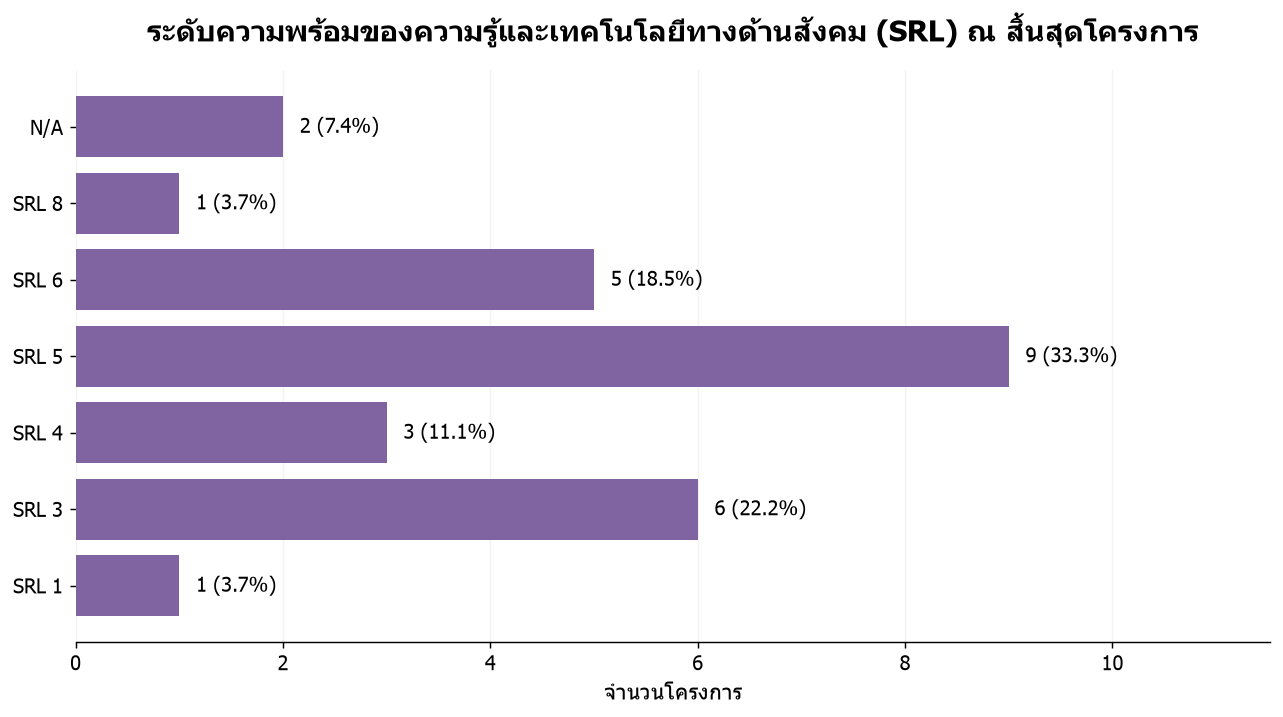

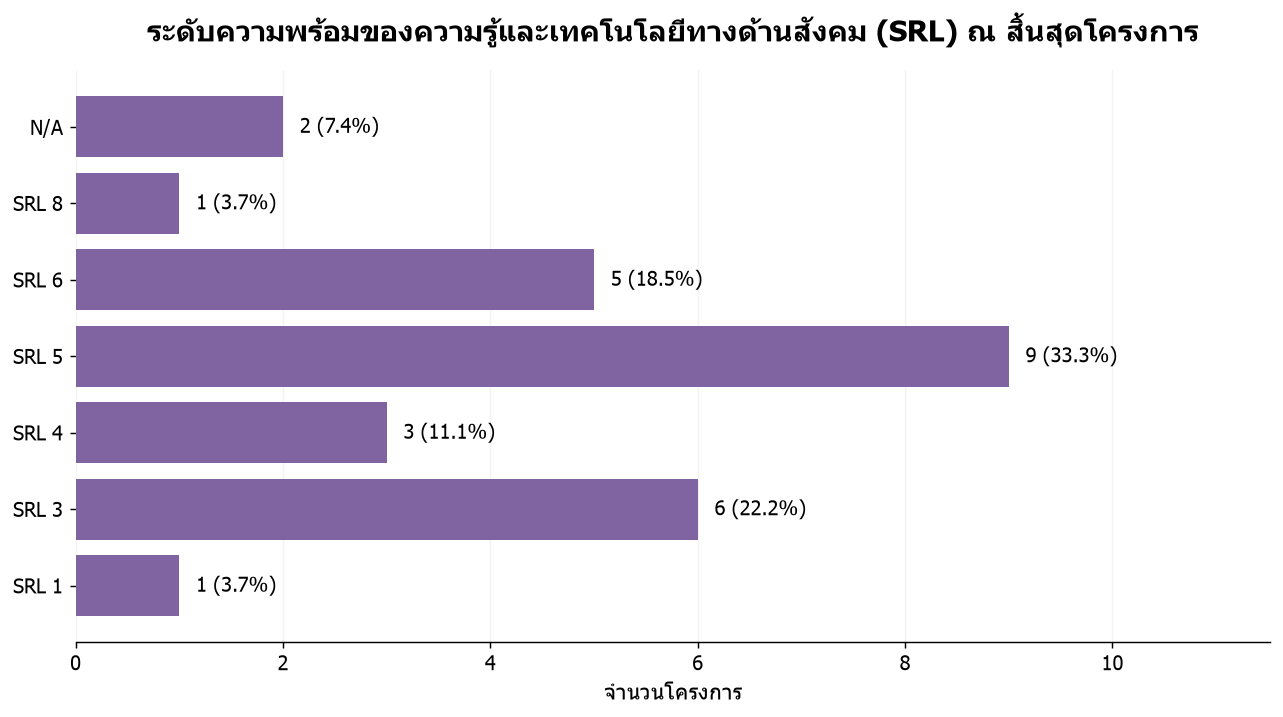

In [ ]:
srl = numeric_prefix(df["SRL สิ้นสุด(Gift)"])
srl_label = srl.map(lambda x: f"SRL {int(x)}" if pd.notna(x) else "N/A")
srl_table = frequency_table(srl_label, denom=N, sort=False)

srl_order = [f"SRL {i}" for i in range(1,10)] + ["N/A"]
srl_table = srl_table.reindex([x for x in srl_order if x in srl_table.index])

srl_budget = (
    df.assign(SRL_label=srl_label)
      .groupby("SRL_label", dropna=False)["งบประมาณที่ได้รับจัดสรร"]
      .sum()
)
srl_table["งบประมาณรวม"] = srl_budget.reindex(srl_table.index)
srl_table["สัดส่วนงบประมาณ"] = srl_table["งบประมาณรวม"]/budget.sum()*100
srl_table["งบรวม (ล้านบาท)"] = srl_table["งบประมาณรวม"]/1e6

display(srl_table[["จำนวน", "ร้อยละ", "งบรวม (ล้านบาท)", "สัดส่วนงบประมาณ"]].round(2))
save_table(srl_table, "4_4_3_srl.csv")

barh_count(
    srl_table[["จำนวน", "ร้อยละ"]],
    "ระดับความพร้อมของความรู้และเทคโนโลยีทางด้านสังคม (SRL) ณ สิ้นสุดโครงการ",
    filename="4_4_3_srl.png",
    color=COLORS["purple"],
    wrap_width=18,
    sort_by_count=False
)


# 4.5 ผลประโยชน์ทางวิชาการ

## 4.5.1 ผลประโยชน์ระดับผลผลิต

รวมจำนวนบทความ การเผยแพร่ ตำรา/คู่มือ สื่อ และการใช้ประโยชน์ด้านการเรียนการสอนตามคอลัมน์ในฐานข้อมูล  
ส่วน “การพัฒนาบุคลากร” มีเพียงตัวแปรที่ฐานข้อมูลรองรับ จึงไม่เติมตัวเลขจากแหล่งอื่น


,จำนวนรวม
จำนวนครั้งการเผยแพร่ผ่านการอบรม/สัมมนา/เวทีสาธารณะ/นิทรรศการ,57.0
จำนวนสื่อ clip vdo หรือเพจเผยแพร่/งานเขียนออนไลน์,22.0
จำนวนคู่มือ/สิ่งพิมพ์,21.0
จำนวนครั้งการเผยแพร่ผ่าน วิดีทัศน์ โทรทัศน์ วิทยุ นสพ. อินเตอร์เน็ต,9.0
จำนวนร่างบทความ (ระดับประเทศ),8.0
จำนวนบทความ (นำเสนอในที่ประชุมระดับประเทศ),6.0
มีการใช้ประโยชน์กับการเรียนการสอน (จำนวนวิชา),6.0
จำนวนบทความ (ระดับประเทศ),3.0
จำนวน ตำรา/หนังสือ (จำนวนเรื่อง),2.0
จำนวนบทความ (ระดับนานาชาติ),1.0


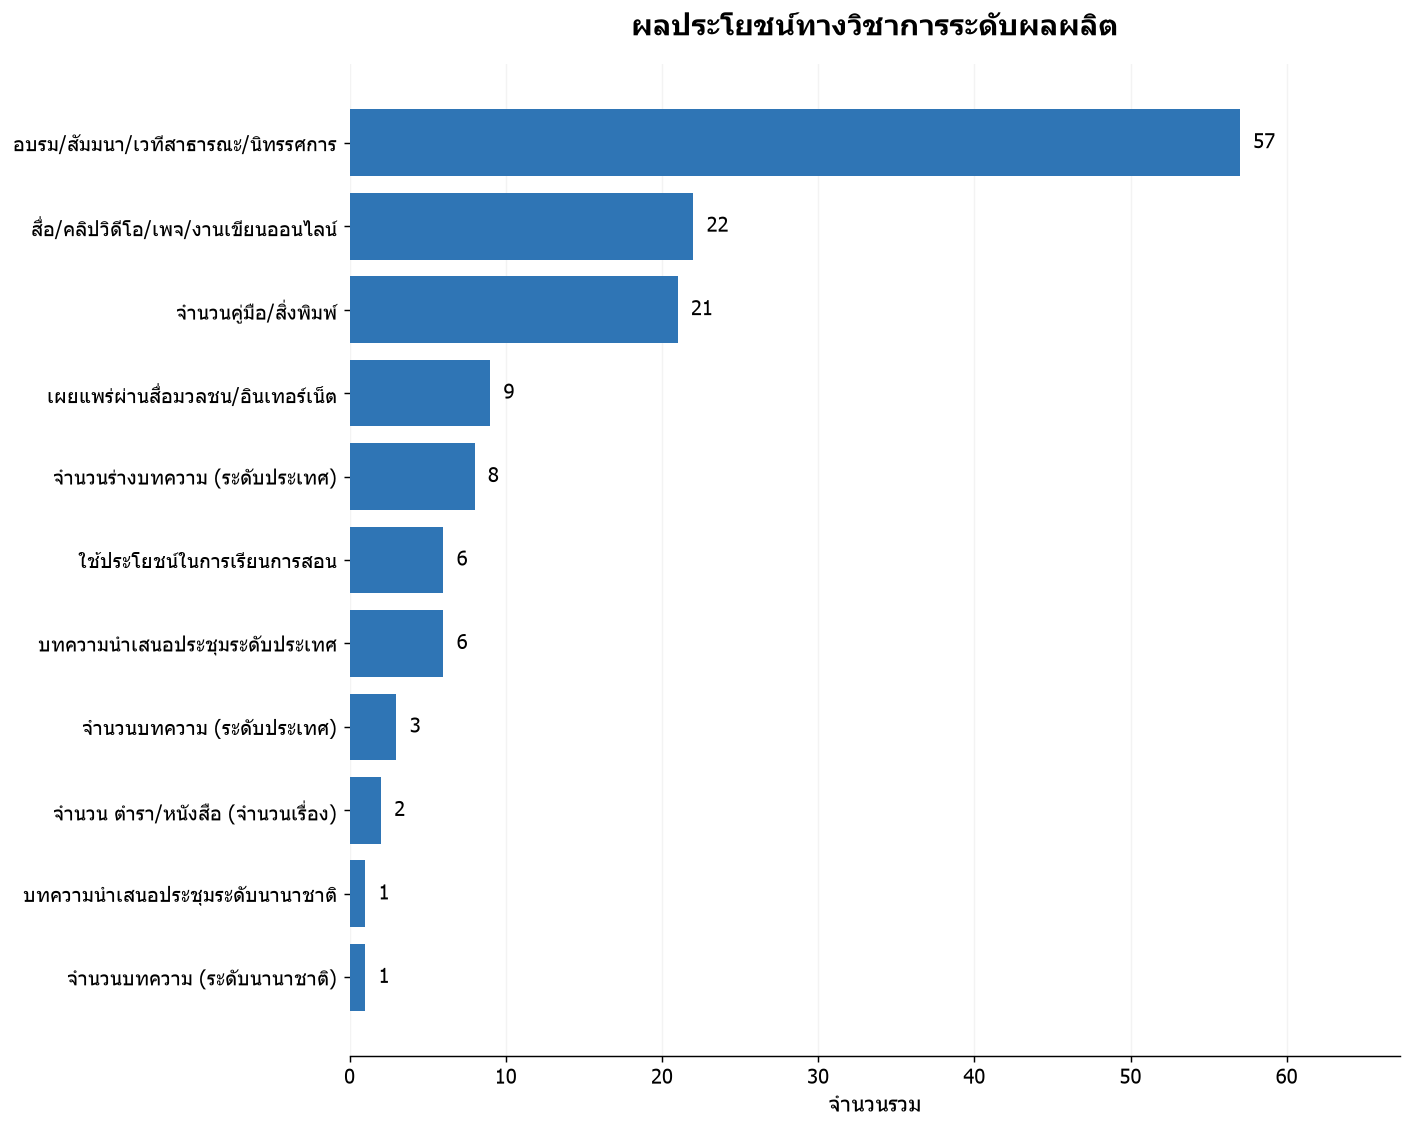

,สิทธิบัตร,อนุสิทธิบัตร
0 = ไม่มี,25,26
2 = รออนุมัติ,0,1
3 = กำลังจะจด,2,0


In [ ]:
academic_cols = [
    "จำนวนบทความ (ระดับนานาชาติ)",
    "จำนวนร่างบทความ (ระดับนานาชาติ)",
    "จำนวนบทความ (ระดับประเทศ)",
    "จำนวนร่างบทความ (ระดับประเทศ)",
    "จำนวนบทความ (นำเสนอในที่ประชุมระดับนานาชาติ)",
    "จำนวนบทความ (นำเสนอในที่ประชุมระดับประเทศ)",
    "จำนวน ตำรา/หนังสือ (จำนวนเรื่อง)",
    "จำนวนคู่มือ/สิ่งพิมพ์",
    "จำนวนครั้งการเผยแพร่ผ่านการอบรม/สัมมนา/เวทีสาธารณะ/นิทรรศการ",
    "จำนวนสื่อ clip vdo หรือเพจเผยแพร่/งานเขียนออนไลน์",
    "จำนวนครั้งการเผยแพร่ผ่าน วิดีทัศน์ โทรทัศน์ วิทยุ นสพ. อินเตอร์เน็ต",
    "มีการใช้ประโยชน์กับการเรียนการสอน (จำนวนวิชา)",
    "มีการใช้ประโยชน์กับการวิจัยเพื่อพัฒนานิสิต (จำนวนนิสิต ที่ทำวิจัยหรือวิทยานิพนธ์)",
]

acad_sum = {}
for c in academic_cols:
    acad_sum[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).sum()

academic_table = (
    pd.Series(acad_sum, name="จำนวนรวม")
      .sort_values(ascending=False)
      .to_frame()
)
display(academic_table)
save_table(academic_table, "4_5_1_academic_benefits.csv")

plot_acad = academic_table[academic_table["จำนวนรวม"] > 0].copy()
if not plot_acad.empty:
    plot_acad = plot_acad.sort_values("จำนวนรวม", ascending=True)
    display_labels = apply_display_labels(plot_acad.index, label_map=ACADEMIC_LABELS, wrap_width=32)
    fig, ax = plt.subplots(figsize=(11, max(6, 0.62*len(plot_acad)+2)))
    bars = ax.barh(display_labels, plot_acad["จำนวนรวม"], color=COLORS["primary"])
    ax.set_title("ผลประโยชน์ทางวิชาการระดับผลผลิต", weight="bold", pad=16, fontsize=CHART_STYLE["title_size"])
    ax.set_xlabel("จำนวนรวม", fontsize=CHART_STYLE["axis_label_size"])
    ax.tick_params(axis="both", labelsize=CHART_STYLE["tick_size"])
    ax.grid(axis="x", alpha=CHART_STYLE["grid_alpha"])
    ax.set_axisbelow(True)
    ax.spines[["top","right","left"]].set_visible(False)
    maxv = max(plot_acad["จำนวนรวม"].max(), 1)
    for b in bars:
        ax.text(b.get_width()+maxv*0.015, b.get_y()+b.get_height()/2,
                f"{int(b.get_width())}", va="center", fontsize=CHART_STYLE["annotation_size"])
    ax.set_xlim(0, maxv*1.18)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR/"4_5_1_academic_benefits.png", dpi=CHART_STYLE["save_dpi"], bbox_inches="tight")
    plt.show()

# ทรัพย์สินทางปัญญา
patent_status = pd.to_numeric(
    df["สิทธิบัตร สถานะ 0= ไม่มี, 1=ได้แล้ว2=รออนุมัติ 3=กำลังจะจด"],
    errors="coerce"
)
petty_patent_status = pd.to_numeric(
    df["อนุสิทธิบัตร สถานะ 0= ไม่มี, 1=ได้แล้ว2=รออนุมัติ 3=กำลังจะจด"],
    errors="coerce"
)

ip_summary = pd.DataFrame({
    "สิทธิบัตร": patent_status.value_counts().sort_index(),
    "อนุสิทธิบัตร": petty_patent_status.value_counts().sort_index(),
}).fillna(0).astype(int)

ip_summary.index = [
    {0:"0 = ไม่มี", 1:"1 = ได้แล้ว", 2:"2 = รออนุมัติ", 3:"3 = กำลังจะจด"}.get(int(i), str(i))
    for i in ip_summary.index
]
display(ip_summary)


## 4.5.2 ผลประโยชน์ทางวิชาการระดับผลลัพธ์

เอกสาร Word ต้องการ “การได้รับอ้างอิงบทความทางวิชาการระดับนานาชาติ” แต่ในชีต `สถานภาพแผนงาน -Clean` **ไม่พบตัวแปรจำนวนการอ้างอิงโดยตรง**  
จึงไม่คำนวณแทนด้วยตัวแปรอื่น เพื่อไม่ให้ความหมายคลาดเคลื่อน


# 4.6 ผลลัพธ์ (Outcome) และผลกระทบ (Impacts)

## 4.6.1.1 กลุ่มผู้ใช้ประโยชน์

ผู้ใช้ประโยชน์เป็น multiple response โดยรวมคอลัมน์ผู้ใช้ประโยชน์ที่ 1–5  
จากนั้นวิเคราะห์ซ้ำเฉพาะโครงการที่ฐานข้อมูลระบุว่า “เกิดผลลัพธ์แล้ว”


,จำนวน,ร้อยละ,n (%)
กลุ่มผู้ใช้ประโยชน์,,,
หน่วยงานภาครัฐในระดับพื้นที่ ตำบล อำเภอ จังหวัด,24,88.888889,24 (88.9%)
ชุมชน/เครือข่าย,13,48.148148,13 (48.1%)
โรงพยาบาล/สถานพยาบาล,8,29.629630,8 (29.6%)
ประชาชนกลุ่มเป้าหมาย,8,29.629630,8 (29.6%)
หน่วยงานรัฐระดับส่วนกลาง/ผู้กำหนดนโยบาย,3,11.111111,3 (11.1%)
ผู้ป่วย,3,11.111111,3 (11.1%)
บุคลากรทางการศึกษา/สถาบันการศึกษา,2,7.407407,2 (7.4%)
ผู้ประกอบการ,2,7.407407,2 (7.4%)
ภาคประชาสังคม/องค์กรชุมชน,2,7.407407,2 (7.4%)


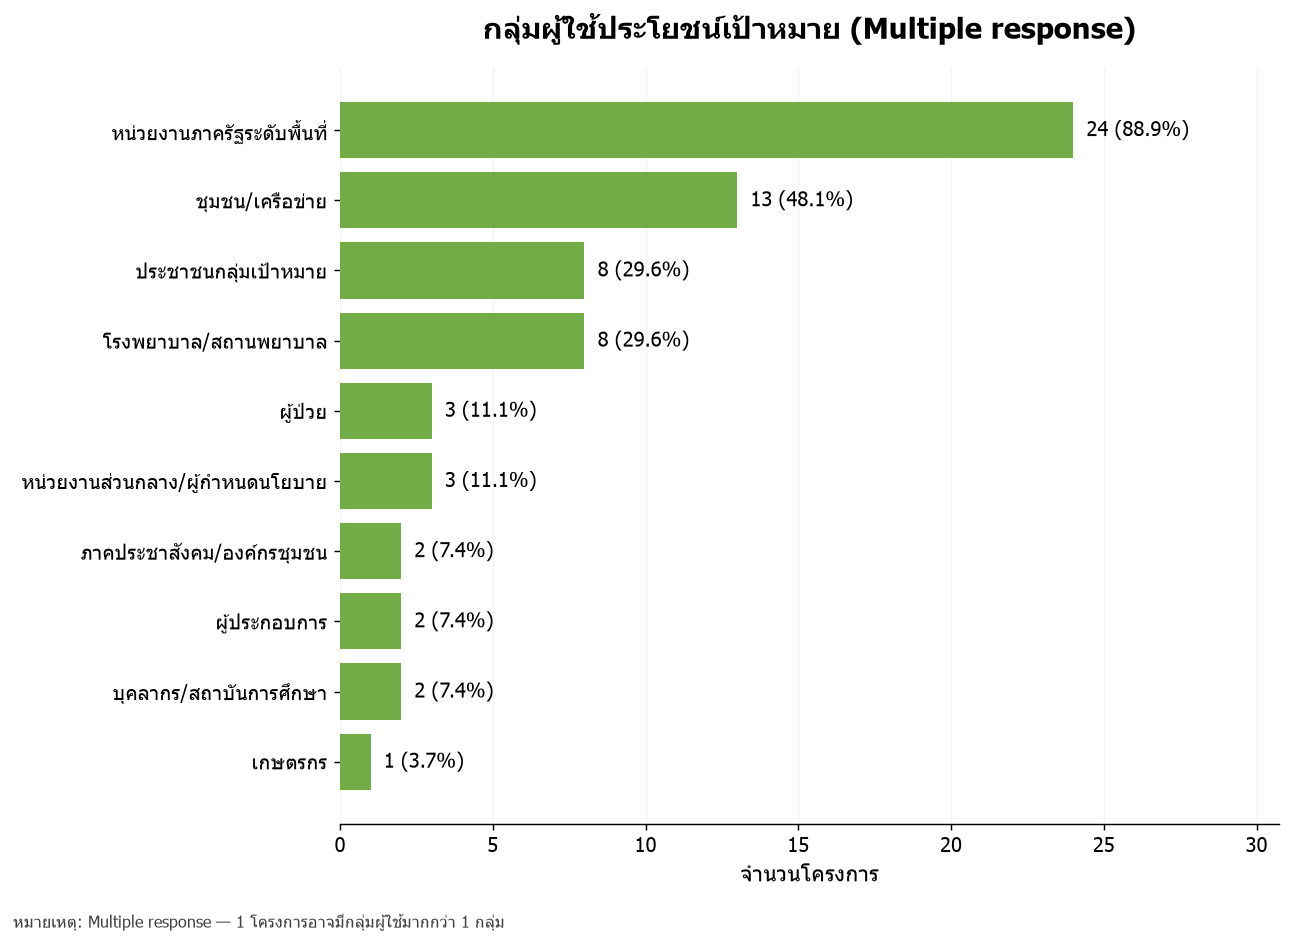

จำนวนโครงการที่ระบุว่าเกิดผลลัพธ์แล้ว: 14


,จำนวน,ร้อยละ,n (%)
กลุ่มผู้ใช้ประโยชน์,,,
หน่วยงานภาครัฐในระดับพื้นที่ ตำบล อำเภอ จังหวัด,14,100.000000,14 (100.0%)
ชุมชน/เครือข่าย,9,64.285714,9 (64.3%)
โรงพยาบาล/สถานพยาบาล,5,35.714286,5 (35.7%)
ประชาชนกลุ่มเป้าหมาย,4,28.571429,4 (28.6%)
ผู้ป่วย,3,21.428571,3 (21.4%)
หน่วยงานรัฐระดับส่วนกลาง/ผู้กำหนดนโยบาย,2,14.285714,2 (14.3%)
ภาคประชาสังคม/องค์กรชุมชน,2,14.285714,2 (14.3%)
บุคลากรทางการศึกษา/สถาบันการศึกษา,1,7.142857,1 (7.1%)
เกษตรกร,1,7.142857,1 (7.1%)


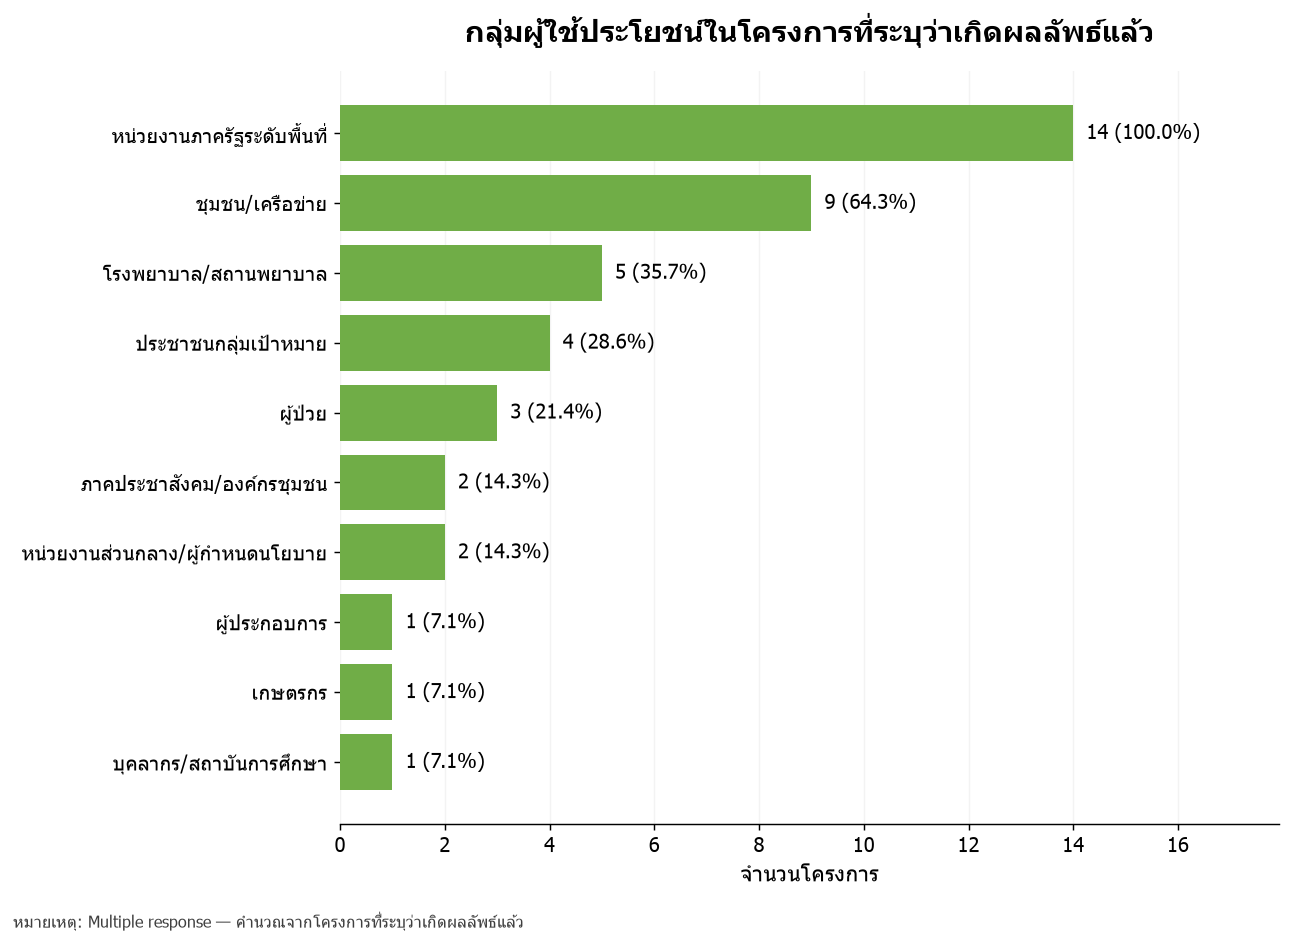

In [ ]:
user_cols = [f"ผู้ใช้ประโยชน์ที่ {i}" for i in range(1,6)]

user_long = (
    df[["รหัสโครงการ", "เกิดผลลัพธ์ แล้วหรือไม่"] + user_cols]
      .melt(
          id_vars=["รหัสโครงการ", "เกิดผลลัพธ์ แล้วหรือไม่"],
          value_vars=user_cols,
          value_name="กลุ่มผู้ใช้ประโยชน์"
      )
      .dropna(subset=["กลุ่มผู้ใช้ประโยชน์"])
)
user_long["กลุ่มผู้ใช้ประโยชน์"] = user_long["กลุ่มผู้ใช้ประโยชน์"].map(clean_text)
user_long = user_long.drop_duplicates(["รหัสโครงการ", "กลุ่มผู้ใช้ประโยชน์"])

user_count = user_long["กลุ่มผู้ใช้ประโยชน์"].value_counts()
user_table = pd.DataFrame({"จำนวน": user_count})
user_table["ร้อยละ"] = user_table["จำนวน"]/N*100
user_table["n (%)"] = [n_pct(n, N) for n in user_table["จำนวน"]]

display(user_table)
barh_count(
    user_table[["จำนวน","ร้อยละ"]],
    "กลุ่มผู้ใช้ประโยชน์เป้าหมาย (Multiple response)",
    filename="4_6_1_1_target_users.png",
    label_map=USER_LABELS,
    wrap_width=28,
    color=COLORS["secondary"],
    note="หมายเหตุ: Multiple response — 1 โครงการอาจมีกลุ่มผู้ใช้มากกว่า 1 กลุ่ม"
)

# เกิดผลลัพธ์แล้ว: รองรับทั้งเลข 1 และข้อความที่ขึ้นต้นด้วย 1
outcome_happened = numeric_prefix(df["เกิดผลลัพธ์ แล้วหรือไม่"]).eq(1)
actual_outcome_ids = set(df.loc[outcome_happened, "รหัสโครงการ"])

actual_user_long = user_long[user_long["รหัสโครงการ"].isin(actual_outcome_ids)]
actual_user_count = actual_user_long["กลุ่มผู้ใช้ประโยชน์"].value_counts()

actual_user_table = pd.DataFrame({"จำนวน": actual_user_count})
actual_denom = len(actual_outcome_ids)
actual_user_table["ร้อยละ"] = actual_user_table["จำนวน"]/actual_denom*100 if actual_denom else 0
actual_user_table["n (%)"] = [n_pct(n, actual_denom) for n in actual_user_table["จำนวน"]]

print("จำนวนโครงการที่ระบุว่าเกิดผลลัพธ์แล้ว:", actual_denom)
display(actual_user_table)

if not actual_user_table.empty:
    barh_count(
        actual_user_table[["จำนวน","ร้อยละ"]],
        "กลุ่มผู้ใช้ประโยชน์ในโครงการที่ระบุว่าเกิดผลลัพธ์แล้ว",
        filename="4_6_1_1_actual_users.png",
        label_map=USER_LABELS,
        wrap_width=28,
        color=COLORS["secondary"],
        note="หมายเหตุ: Multiple response — คำนวณจากโครงการที่ระบุว่าเกิดผลลัพธ์แล้ว"
    )


## 4.6.1.2 ประเภทผลลัพธ์ของงานวิจัย

รวมผลลัพธ์ที่ 1–5 เป็น multiple response และสามารถ cross-tab ตามขนาดโครงการ ประเภทการวิจัย และกลุ่มผู้ใช้ประโยชน์ได้


,จำนวน,ร้อยละ,n (%)
ประเภทผลลัพธ์,,,
เพิ่มผลิตภาพการผลิต/เพิ่มผลผลิต,18,66.666667,18 (66.7%)
สร้างเครือข่ายและความร่วมมือทางสังคม,16,59.259259,16 (59.3%)
พัฒนาคุณภาพชีวิต,11,40.740741,11 (40.7%)
ลดความสูญเสียทางเศรษฐกิจสังคม เช่น ลดอัตราการเจ็บป่วย ลดอัตราการตาย และลดค่าใช้จ่ายด้านสุขภาพ เป็นต้น,11,40.740741,11 (40.7%)
พัฒนาชุมชน,6,22.222222,6 (22.2%)
เพิ่มรายได้,4,14.814815,4 (14.8%)
ลดขยะและของเสีย,2,7.407407,2 (7.4%)
คุณภาพสิ่งแวดล้อมดีขึ้น ลดมลพิษ/มลภาวะ/ลดก๊าซเรือนกระจก,1,3.703704,1 (3.7%)
พัฒนาคุณภาพชีวิต (เพราะเข้าถึงบริการสุขภาพคุณภาพมาตรฐาน),1,3.703704,1 (3.7%)


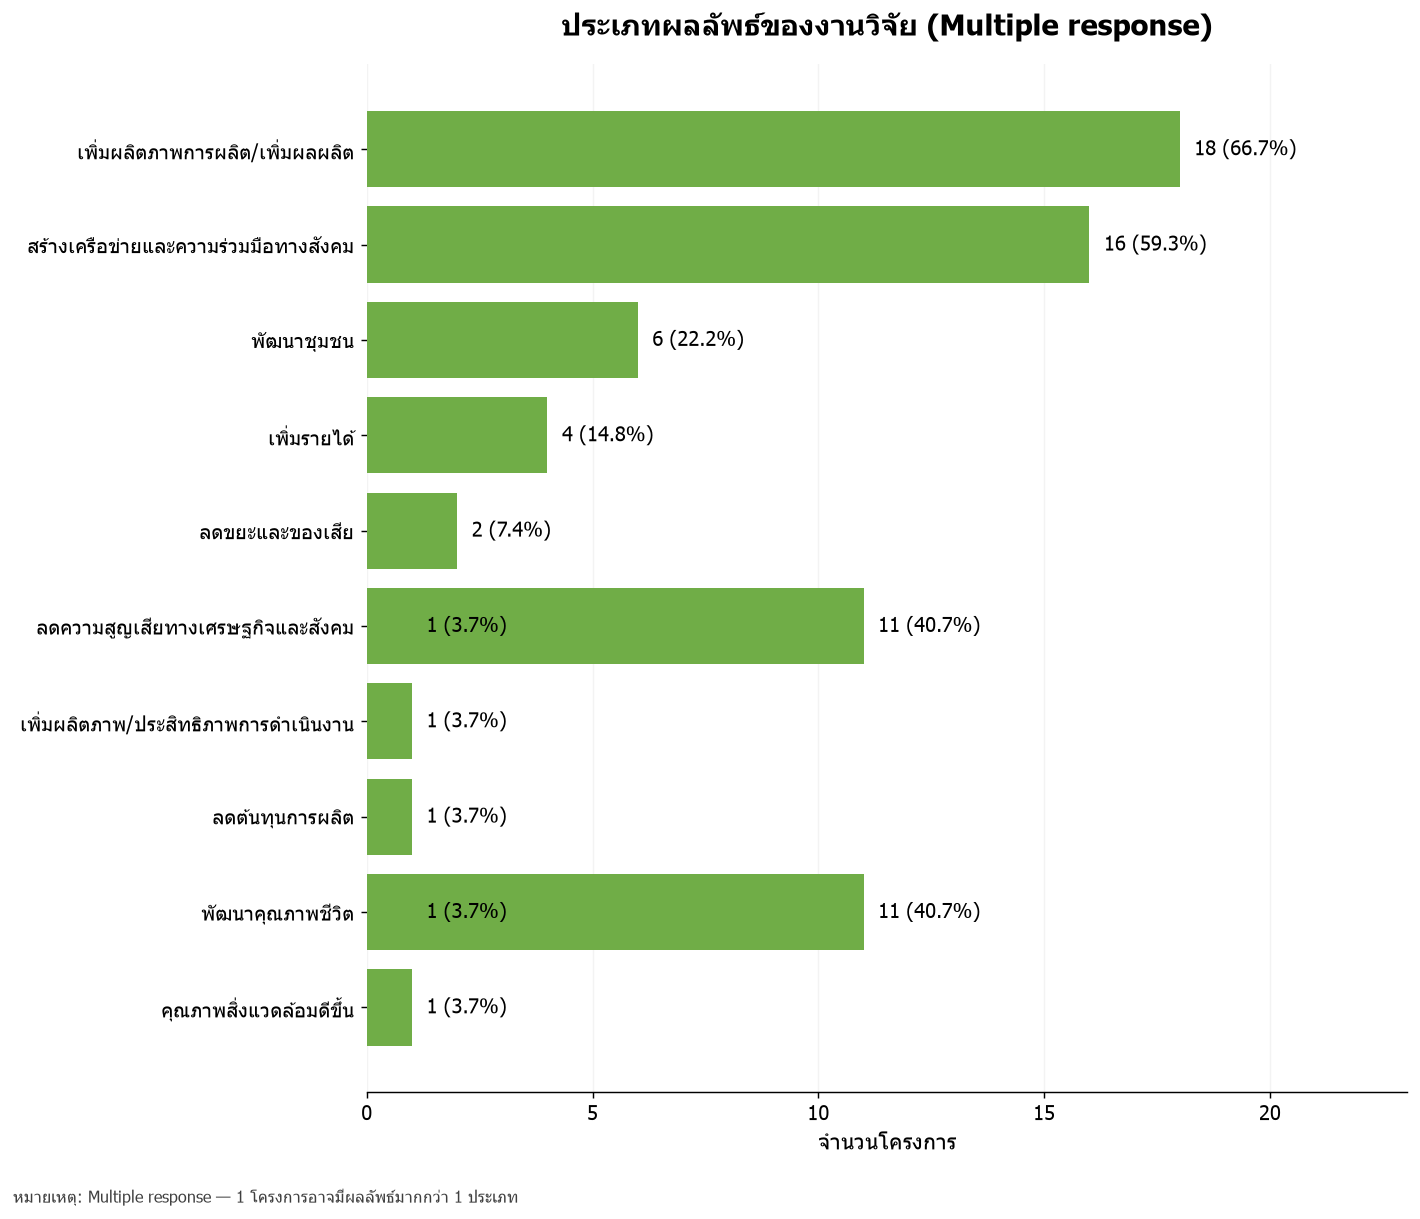

ผลลัพธ์ x ขนาดโครงการ


ขนาดโครงการ,ขนาดกลาง,ขนาดเล็ก,ขนาดใหญ่
ประเภทผลลัพธ์,,,
คุณภาพสิ่งแวดล้อมดีขึ้น ลดมลพิษ/มลภาวะ/ลดก๊าซเรือนกระจก,1,0,0
พัฒนาคุณภาพชีวิต,5,0,6
พัฒนาคุณภาพชีวิต (เพราะเข้าถึงบริการสุขภาพคุณภาพมาตรฐาน),1,0,0
พัฒนาชุมชน,3,0,3
ลดขยะและของเสีย,1,0,1
ลดความสูญเสียทางเศรษฐกิจสังคม เช่น ลดอัตราการเจ็บป่วย ลดอัตราการตาย และลดค่าใช้จ่ายด้านสุขภาพ เป็นต้น,8,0,3
ลดความสูญเสียทางเศรษฐกิจและสังคม,0,0,1
ลดต้นทุนการผลิต,0,0,1
สร้างเครือข่ายและความร่วมมือทางสังคม,8,1,7


ผลลัพธ์ x ประเภทการวิจัย


ประเภทของการวิจัย,การพัฒนาเชิงทดลอง,การวิจัยเชิงนโยบาย,การวิจัยเชิงประยุกต์
ประเภทผลลัพธ์,,,
คุณภาพสิ่งแวดล้อมดีขึ้น ลดมลพิษ/มลภาวะ/ลดก๊าซเรือนกระจก,0,1,0
พัฒนาคุณภาพชีวิต,0,1,10
พัฒนาคุณภาพชีวิต (เพราะเข้าถึงบริการสุขภาพคุณภาพมาตรฐาน),0,1,0
พัฒนาชุมชน,0,0,6
ลดขยะและของเสีย,0,0,2
ลดความสูญเสียทางเศรษฐกิจสังคม เช่น ลดอัตราการเจ็บป่วย ลดอัตราการตาย และลดค่าใช้จ่ายด้านสุขภาพ เป็นต้น,1,1,9
ลดความสูญเสียทางเศรษฐกิจและสังคม,0,0,1
ลดต้นทุนการผลิต,0,0,1
สร้างเครือข่ายและความร่วมมือทางสังคม,3,0,13


In [ ]:
outcome_cols = [f"ผลลัพธ์ที่ {i}" for i in range(1,6)]

outcome_long = (
    df[["รหัสโครงการ", "ขนาดโครงการ", research_type_col] + outcome_cols]
      .melt(
          id_vars=["รหัสโครงการ", "ขนาดโครงการ", research_type_col],
          value_vars=outcome_cols,
          value_name="ประเภทผลลัพธ์"
      )
      .dropna(subset=["ประเภทผลลัพธ์"])
)
outcome_long["ประเภทผลลัพธ์"] = outcome_long["ประเภทผลลัพธ์"].map(clean_text)
outcome_long = outcome_long.drop_duplicates(["รหัสโครงการ", "ประเภทผลลัพธ์"])

outcome_count = outcome_long["ประเภทผลลัพธ์"].value_counts()
outcome_table = pd.DataFrame({"จำนวน": outcome_count})
outcome_table["ร้อยละ"] = outcome_table["จำนวน"]/N*100
outcome_table["n (%)"] = [n_pct(n, N) for n in outcome_table["จำนวน"]]

display(outcome_table)
save_table(outcome_table, "4_6_1_2_outcome_types.csv")

barh_count(
    outcome_table[["จำนวน","ร้อยละ"]],
    "ประเภทผลลัพธ์ของงานวิจัย (Multiple response)",
    filename="4_6_1_2_outcome_types.png",
    label_map=OUTCOME_LABELS,
    wrap_width=32,
    color=COLORS["secondary"],
    figsize=(11, max(6, 0.62*len(outcome_table)+2)),
    note="หมายเหตุ: Multiple response — 1 โครงการอาจมีผลลัพธ์มากกว่า 1 ประเภท"
)

print("ผลลัพธ์ x ขนาดโครงการ")
display(pd.crosstab(outcome_long["ประเภทผลลัพธ์"], outcome_long["ขนาดโครงการ"]))

print("ผลลัพธ์ x ประเภทการวิจัย")
display(pd.crosstab(outcome_long["ประเภทผลลัพธ์"], outcome_long[research_type_col]))


## 4.6.2 ผลกระทบ

ฐานข้อมูลระบุ `0/1` ว่าโครงการมีผลกระทบ **ที่เกิดขึ้นหรือคาดว่าจะเกิดขึ้น** ในมิติเศรษฐกิจ สังคม และสิ่งแวดล้อม  
กราฟนี้จึงควรเขียนคำกำกับว่า **“เกิดขึ้น/คาดว่าจะเกิดขึ้น”** และไม่ตีความทุกค่า 1 ว่าเป็น Actual Impact


,จำนวน,ร้อยละ,n (%)
มิติผลกระทบ,,,
เศรษฐกิจ,21,77.777778,21 (77.8%)
สังคม,23,85.185185,23 (85.2%)
สิ่งแวดล้อม,4,14.814815,4 (14.8%)


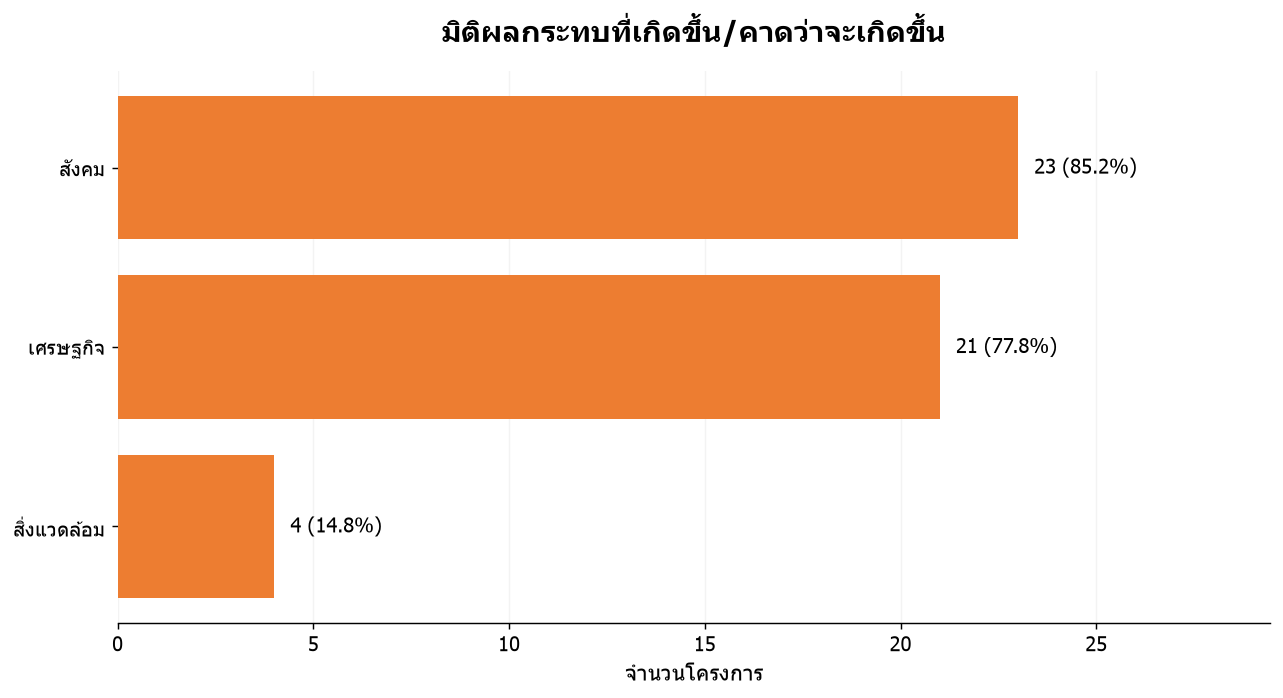


เศรษฐกิจ — จำแนกตามขนาดโครงการ


,จำนวน
ขนาดโครงการ,
ขนาดกลาง,12
ขนาดใหญ่,8
ขนาดเล็ก,1


เศรษฐกิจ — จำแนกตามประเภทการวิจัย


,จำนวน
ประเภทของการวิจัย,
การวิจัยเชิงประยุกต์,17
การวิจัยเชิงนโยบาย,2
การพัฒนาเชิงทดลอง,2



สังคม — จำแนกตามขนาดโครงการ


...

,จำนวน
ประเภทของการวิจัย,
การวิจัยเชิงประยุกต์,18
การพัฒนาเชิงทดลอง,3
การวิจัยเชิงนโยบาย,2



สิ่งแวดล้อม — จำแนกตามขนาดโครงการ


,จำนวน
ขนาดโครงการ,
ขนาดกลาง,3
ขนาดใหญ่,1


สิ่งแวดล้อม — จำแนกตามประเภทการวิจัย


,จำนวน
ประเภทของการวิจัย,
การวิจัยเชิงประยุกต์,3
การวิจัยเชิงนโยบาย,1


In [ ]:
impact_cols = {
    "เศรษฐกิจ": "ด้านเศรษฐกิจ",
    "สังคม": "ด้านสังคม",
    "สิ่งแวดล้อม": "ด้านสิ่งแวดล้อม"
}

impact_rows = []
for label, col in impact_cols.items():
    vals = pd.to_numeric(df[col], errors="coerce")
    n = vals.eq(1).sum()
    impact_rows.append([label, n, n/N*100])

impact_table = pd.DataFrame(
    impact_rows,
    columns=["มิติผลกระทบ", "จำนวน", "ร้อยละ"]
).set_index("มิติผลกระทบ")
impact_table["n (%)"] = [n_pct(n, N) for n in impact_table["จำนวน"]]

display(impact_table)
save_table(impact_table, "4_6_2_impact_dimensions.csv")

barh_count(
    impact_table[["จำนวน","ร้อยละ"]],
    "มิติผลกระทบที่เกิดขึ้น/คาดว่าจะเกิดขึ้น",
    filename="4_6_2_impact_dimensions.png",
    color=COLORS["accent"],
    wrap_width=24
)

# จำแนกผลกระทบตามขนาดโครงการและประเภทการวิจัย
for label, col in impact_cols.items():
    temp = df.loc[pd.to_numeric(df[col], errors="coerce").eq(1)]
    print(f"\n{label} — จำแนกตามขนาดโครงการ")
    display(temp["ขนาดโครงการ"].value_counts().to_frame("จำนวน"))
    print(f"{label} — จำแนกตามประเภทการวิจัย")
    display(temp[research_type_col].value_counts().to_frame("จำนวน"))


# 4.7 การประเมินผลสำเร็จตามเกณฑ์ OECD

วิเคราะห์ 6 มิติ:
1. Relevance
2. Coherence
3. Effectiveness
4. Efficiency
5. Outcomes & Impact
6. Sustainability

สำหรับกราฟใยแมงมุมด้านล่าง:
- 4 มิติแรกใช้ **สัดส่วนโครงการที่ได้ค่า 1**
- Outcomes & Impact ใช้ค่า 0–3 แล้วหาร 3 เพื่อ normalize เป็น 0–1 และ **ตัดรหัส 4 = N/A ออก**
- Sustainability ใช้ระดับ 1–3 โดย **1 = ยั่งยืนกว่า, 3 = ไม่ยั่งยืนกว่า** จึงแปลงเป็น `(3-score)/2`; รหัส 4 = N/A ถูกตัดออก
- กราฟนี้เป็น **descriptive normalized summary** เพื่อสื่อสารภาพรวม ไม่ใช่คะแนน OECD มาตรฐานอย่างเป็นทางการ


,จำนวนผ่าน,จำนวนที่มีข้อมูล,ร้อยละผ่าน
เกณฑ์,,,
Relevance,27,27,100.00
Coherence,27,27,100.00
Effectiveness,25,27,92.59
Efficiency,21,27,77.78


### Outcomes & Impact

,จำนวน,ร้อยละ,n (%)
Outcomes and Impact (Dropdownlist),,,
2.0,15,55.555556,15 (55.6%)
1.0,7,25.925926,7 (25.9%)
4.0,2,7.407407,2 (7.4%)
NaN,2,7.407407,2 (7.4%)
0.0,1,3.703704,1 (3.7%)


### Sustainability

,จำนวน,ร้อยละ,n (%)
Sustainability (Dropdownlist),,,
2.0,14,51.851852,14 (51.9%)
4.0,11,40.740741,11 (40.7%)
NaN,2,7.407407,2 (7.4%)


,มิติ,ค่าปรับมาตรฐาน 0–1
0,Relevance,1.000
1,Coherence,1.000
2,Effectiveness,0.926
3,Efficiency,0.778
4,Outcome & Impact,0.536
5,Sustainability,0.500


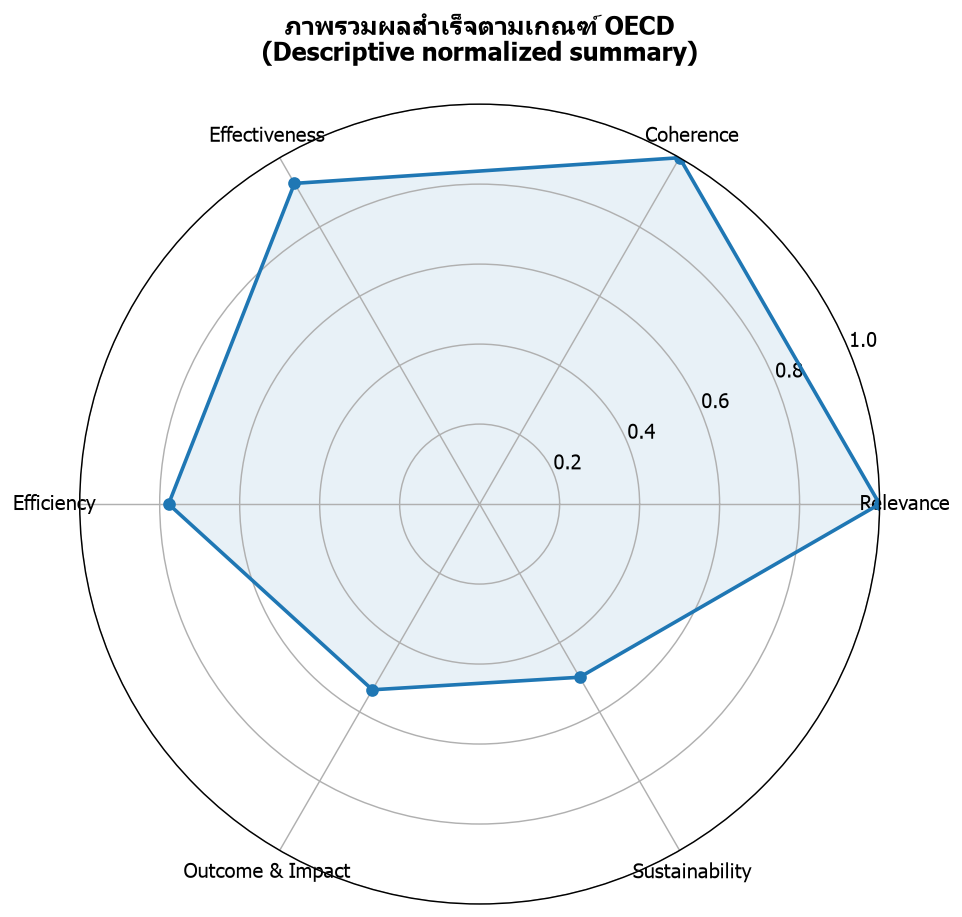

In [ ]:
binary_oecd = {
    "Relevance": "Relevance (0-ไม่มี, 1 -มี)",
    "Coherence": "Coherence (0-ไม่มี, 1 -มี)",
    "Effectiveness": "Effectiveness (0-ไม่มี, 1 -มี)",
    "Efficiency": "Efficiency (0-ไม่มี, 1 -มี)",
}

oecd_summary_rows = []
for label, col in binary_oecd.items():
    vals = pd.to_numeric(df[col], errors="coerce")
    n1 = vals.eq(1).sum()
    valid = vals.notna().sum()
    oecd_summary_rows.append([label, n1, valid, n1/valid*100 if valid else np.nan])

oecd_binary_table = pd.DataFrame(
    oecd_summary_rows,
    columns=["เกณฑ์", "จำนวนผ่าน", "จำนวนที่มีข้อมูล", "ร้อยละผ่าน"]
).set_index("เกณฑ์")
display(oecd_binary_table.round(2))

# Distribution: Outcome & Impact
oi_score = numeric_prefix(df["Outcomes and Impact (Dropdownlist)"])
oi_table = frequency_table(oi_score, denom=N, dropna=False, sort=False)
display(Markdown("### Outcomes & Impact"))
display(oi_table)

# Distribution: Sustainability
sus_score = numeric_prefix(df["Sustainability (Dropdownlist)"])
sus_table = frequency_table(sus_score, denom=N, dropna=False, sort=False)
display(Markdown("### Sustainability"))
display(sus_table)

# Radar normalized summary
radar_labels = ["Relevance", "Coherence", "Effectiveness", "Efficiency", "Outcome & Impact", "Sustainability"]

radar_values = []
for label in radar_labels[:4]:
    radar_values.append(oecd_binary_table.loc[label, "ร้อยละผ่าน"]/100)

oi_valid = oi_score[oi_score.isin([0,1,2,3])]
radar_values.append((oi_valid/3).mean() if len(oi_valid) else np.nan)

sus_valid = sus_score[sus_score.isin([1,2,3])]
radar_values.append(((3-sus_valid)/2).mean() if len(sus_valid) else np.nan)

radar_df = pd.DataFrame({"มิติ": radar_labels, "ค่าปรับมาตรฐาน 0–1": radar_values})
display(radar_df.round(3))

angles = np.linspace(0, 2*np.pi, len(radar_labels), endpoint=False).tolist()
values = radar_values + radar_values[:1]
angles_closed = angles + angles[:1]

fig = plt.figure(figsize=(7.5, 7.5))
ax = fig.add_subplot(111, polar=True)
ax.plot(angles_closed, values, linewidth=2, marker="o")
ax.fill(angles_closed, values, alpha=0.10)
ax.set_xticks(angles)
ax.set_xticklabels(radar_labels)
ax.set_ylim(0, 1)
ax.set_yticks([0.2,0.4,0.6,0.8,1.0])
ax.set_yticklabels(["0.2","0.4","0.6","0.8","1.0"])
ax.set_title("ภาพรวมผลสำเร็จตามเกณฑ์ OECD\n(Descriptive normalized summary)", pad=24, weight="bold")
fig.tight_layout()
fig.savefig(OUTPUT_DIR/"4_7_oecd_radar.png", bbox_inches="tight")
plt.show()


## ตารางสรุปสำหรับนำไปเขียนบทที่ 4

Cell ด้านล่างสร้างตารางสรุปตัวเลขหลักแบบสั้น เพื่อคัดลอกไปใช้เขียน narrative ได้ทันที


In [ ]:
summary_rows = [
    ["จำนวนโครงการทั้งหมด", N, "100.0%"],
    ["งบประมาณรวม (ล้านบาท)", round(budget.sum()/1e6, 2), ""],
    ["งบประมาณเฉลี่ยต่อโครงการ (ล้านบาท)", round(budget.mean()/1e6, 2), ""],
    ["โครงการขยายเวลา", int(extended.sum()), f"{extended.mean()*100:.1f}%"],
    ["โครงการยุติ", int(terminated.sum()), f"{terminated.mean()*100:.1f}%"],
    ["นักวิจัยรวม (คน)", int(researcher_n.sum()), ""],
    ["นักวิจัยเฉลี่ยต่อโครงการ (คน)", round(researcher_n.mean(), 2), ""],
]

chapter4_summary = pd.DataFrame(summary_rows, columns=["ตัวชี้วัด", "จำนวน/ค่า", "ร้อยละ"])
display(chapter4_summary)
chapter4_summary.to_csv(OUTPUT_DIR/"chapter4_key_summary.csv", index=False, encoding="utf-8-sig")

print(f"บันทึกกราฟและตารางไว้ที่: {OUTPUT_DIR.resolve()}")


,ตัวชี้วัด,จำนวน/ค่า,ร้อยละ
0,จำนวนโครงการทั้งหมด,27.00,100.0%
1,งบประมาณรวม (ล้านบาท),90.00,
2,งบประมาณเฉลี่ยต่อโครงการ (ล้านบาท),3.33,
3,โครงการขยายเวลา,4.00,14.8%
4,โครงการยุติ,2.00,7.4%
5,นักวิจัยรวม (คน),151.00,
6,นักวิจัยเฉลี่ยต่อโครงการ (คน),5.59,


บันทึกกราฟและตารางไว้ที่: /Users/nagasu/VSCodeProjects/MLDataAnalytics/EvaluateProject/chapter4_outputs


# หมายเหตุสำหรับการเขียนรายงาน

- ทุกกราฟควรใช้ชื่อเดียวกับหัวข้อในบทที่ 4 และใส่ `n (%)` ให้สอดคล้องกันทั้งเล่ม
- กราฟ Multiple response ต้องมีเชิงอรรถว่า **“โครงการหนึ่งสามารถอยู่ได้มากกว่า 1 ประเภท จึงรวมร้อยละเกิน 100% ได้”**
- Impact ต้องแยกถ้อยคำ **Actual / Expected** ในการเขียน narrative จาก Note ของแต่ละโครงการ ไม่ควรสรุปค่า 1 ทั้งหมดเป็นผลกระทบที่เกิดขึ้นจริง
- ส่วนผลประโยชน์วิชาการระดับ Outcome เรื่อง citation ยังไม่มีตัวแปรตรงในชีตนี้ จึงควรระบุว่า “ไม่มีข้อมูลสำหรับวิเคราะห์” หรือเติมจากแหล่งข้อมูลอื่นภายหลัง
- หากต้องการรวมคำตอบที่สะกดต่างกันแต่มีความหมายเดียวกัน ควรทำ **canonical mapping ที่ตรวจสอบโดยผู้วิจัย** ก่อนสร้างกราฟฉบับเผยแพร่
